In [1]:
# =============================================================================
# [셀 1] 02_Factor_05_F_quality.ipynb — 환경 / 경로 / 유틸 / 설계 메모
# =============================================================================
# 목적:
#   - F-score (Piotroski) 기반 퀄리티 팩터 단독 검증
#   - 가설: F-1 "좋은 기업은 결국 버틴다" (퀄리티 프리미엄)
#
# 산출물:
#   - 이 셀: 환경 설정만 (데이터 로드는 셀 2)
#
# 주의:
#   - fundamentals_quarterly.parquet v2 필요 (F-score 확장 컬럼 12개)
#   - 01_DataLoader_Quarterly.ipynb 셀 2 v2 실행 완료 전제
# =============================================================================
#
# ★★★ F-SCORE 버전 설계 메모 ★★★
# -----------------------------------------------------------------
# Piotroski F-score 9개 시그널 중 일부는 구조적 NaN 발생
#   - ΔMargin (GrossProfit): 금융/유틸/부동산 + 일부 서비스 (~43% NaN)
#   - ΔLiquidity (AssetsCurrent/LiabilitiesCurrent): 금융주 (~17.5% NaN)
#   - ΔLeverage (LongTermDebt): 금융주 (~17.5% NaN, LiabCurrent 역산)
#   - Equity Issuance (SharesOutstanding): ~1.5% NaN (거의 전종목 커버)
#
# 이에 따라 3+1 버전으로 백테스트:
#   버전 A: NaN 시그널 → 0점 (neutral) 처리. 전 종목 포함.
#   버전 B-1: 구조적 NaN 섹터 (Financials, Utilities, Real Estate) 제외.
#             나머지 섹터만으로 F-score 9/9 테스트.
#   버전 B-2: 섹터 무관, 개별 시그널 NaN인 관측치만 해당 시그널 제외.
#             종목별·시점별 유효 시그널 수가 달라짐 → 정규화 필요.
#   버전 C: GrossProfit NaN → OperatingIncomeLoss/Revenue로 ΔMargin 대체.
#           AssetsCurrent/LiabilitiesCurrent NaN → ΔLiquidity 0점.
#           가장 현실적 버전. 최종 채택 후보.
#
# 비교 기준: 버전 간 Sharpe, t-stat, IR 차이 → 어떤 처리가 가장 robust한지 판단
# -----------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 경로 설정 (SSOT)
# -----------------------------
QP2_ROOT = Path(r"C:\QP2")
DATA_DIR = QP2_ROOT / "data"
RAW_DIR  = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
META_DIR = DATA_DIR / "meta"

PATHS = {
    "px_wide":    INTERIM_DIR / "yahoo_adjclose_wide_20130619.parquet",
    "ret_1m":     INTERIM_DIR / "yahoo_returns_monthly_wide_20130619.parquet",
    "fund_q":     INTERIM_DIR / "fundamentals_quarterly.parquet",
    "mktcap_m":   INTERIM_DIR / "mktcap_monthly.parquet",
    "universe":   META_DIR / "sp500_universe.parquet",
}

# 존재 확인
for name, p in PATHS.items():
    if not p.exists():
        raise FileNotFoundError(f"필수 파일 없음: {name} → {p}")


# -----------------------------
# 설정 상수
# -----------------------------
LAG_DAYS = 30           # 재무 공시(filed_date) 이후 반영 시차 (일)
                        # ★ sensitivity test 예정: [0, 30, 90]
                        #   0  = filed 즉시 (look-ahead는 filed_date로 방지)
                        #   30 = 시장 소화 기간 1개월
                        #   90 = 보수적 (A팩터에서는 180 사용했으나 F는 다름)
TOP_N = 30              # 포트폴리오 상위 N 종목 (프로젝트 공통)
COST_BP = 20            # 편도 거래비용 (bps)
# ★ F-score 전용 설정
STRUCT_NAN_SECTORS = ["Financials", "Utilities", "Real Estate"]  # 구조적 NaN 섹터

# -----------------------------
# 공통 유틸 함수
# -----------------------------
def winsorize(s: pd.Series, lower=0.01, upper=0.99) -> pd.Series:
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df: pd.DataFrame, col: str, out: str = None) -> pd.DataFrame:
    """날짜(date)별 횡단면 z-score"""
    if out is None:
        out = col + "_z"
    df = df.copy()
    g = df.groupby("date")[col]
    df[out] = g.transform(lambda x: (x - x.mean()) / x.std())
    return df

def map_fy_to_effective_date(fy_series, fp_series, filed_series, lag_days=LAG_DAYS):
    """
    재무 데이터의 유효 시작일 계산.
    effective_date = filed_date + lag_days
    filed가 NaN이면 (fy, fp) 기반 추정.
    """
    filed_dt = pd.to_datetime(filed_series, errors="coerce")
    effective = filed_dt + pd.Timedelta(days=lag_days)
    
    # filed가 NaN인 경우 fallback: 분기 끝 + 60일(공시 추정) + lag
    fp_offset = fp_series.map({"Q1": 3, "Q2": 6, "Q3": 9, "Q4": 12}).fillna(12).astype(int)
    fallback_end = pd.to_datetime(fy_series.astype(str) + "-01-01") + \
                   pd.to_timedelta(fp_offset * 30.44, unit="D")
    fallback_effective = fallback_end + pd.Timedelta(days=60 + lag_days)
    
    effective = effective.fillna(fallback_effective)
    return effective

print("✅ [셀 1] 환경 설정 완료")
print(f"   QP2_ROOT: {QP2_ROOT}")
print(f"   LAG_DAYS: {LAG_DAYS}")
print(f"   TOP_N: {TOP_N}")
print(f"   COST_BP: {COST_BP}")
print(f"   구조적 NaN 섹터: {STRUCT_NAN_SECTORS}")
for name, p in PATHS.items():
    print(f"   {name}: ✅")

✅ [셀 1] 환경 설정 완료
   QP2_ROOT: C:\QP2
   LAG_DAYS: 30
   TOP_N: 30
   COST_BP: 20
   구조적 NaN 섹터: ['Financials', 'Utilities', 'Real Estate']
   px_wide: ✅
   ret_1m: ✅
   fund_q: ✅
   mktcap_m: ✅
   universe: ✅


In [2]:
# =============================================================================
# [셀 2] 데이터 로드 + 정합성 확인
# =============================================================================
# 목적:
#   - 주가, 수익률, 재무(분기), 시가총액, 유니버스 로드
#   - F-score 계산에 필요한 컬럼 존재 확인
#   - 재무 데이터에 effective_date 부여 (look-ahead 방지)
#
# 산출물:
#   - px_wide, ret_1m, fund_q, mktcap_m, universe (메모리)
#   - fund_q에 effective_date 컬럼 추가
#
# 주의:
#   - fund_q는 fundamentals_quarterly v2 (12개 컬럼) 전제
#   - ret_1m이 wide면 long 변환 필요할 수 있음

# -----------------------------
# 1) 로드
# -----------------------------
px_wide = pd.read_parquet(PATHS["px_wide"])
ret_1m_raw = pd.read_parquet(PATHS["ret_1m"])
fund_q = pd.read_parquet(PATHS["fund_q"])
mktcap_m = pd.read_parquet(PATHS["mktcap_m"])
universe = pd.read_parquet(PATHS["universe"])

# -----------------------------
# 2) ret_1m: wide → long 변환 (필요시)
# -----------------------------
if "ticker" not in ret_1m_raw.columns:
    if "date" in ret_1m_raw.columns:
        ret_1m_raw = ret_1m_raw.set_index("date")
    if not isinstance(ret_1m_raw.index, pd.DatetimeIndex):
        ret_1m_raw.index = pd.to_datetime(ret_1m_raw.index)
    ret_1m = ret_1m_raw.stack().reset_index()
    ret_1m.columns = ["date", "ticker", "ret_1m"]
else:
    ret_1m = ret_1m_raw.copy()
    if "date" not in ret_1m.columns and ret_1m.index.name == "date":
        ret_1m = ret_1m.reset_index()

ret_1m["date"] = pd.to_datetime(ret_1m["date"])
ret_1m["ret_1m"] = pd.to_numeric(ret_1m["ret_1m"], errors="coerce")
ret_1m = ret_1m.dropna(subset=["ret_1m"])
print(f"✅ ret_1m: {len(ret_1m):,} rows, {ret_1m['ticker'].nunique()} tickers")
print(f"   ret_1m dtype: {ret_1m['ret_1m'].dtype}")

# -----------------------------
# 3) px_wide: index 확인
# -----------------------------
if not isinstance(px_wide.index, pd.DatetimeIndex):
    if "date" in px_wide.columns:
        px_wide = px_wide.set_index("date")
    px_wide.index = pd.to_datetime(px_wide.index)
print(f"✅ px_wide: {px_wide.shape[0]} dates × {px_wide.shape[1]} tickers")

# -----------------------------
# 4) mktcap_m: 형태 확인
# -----------------------------
if "date" in mktcap_m.columns and "ticker" in mktcap_m.columns:
    pass  # 이미 long
elif "date" not in mktcap_m.columns and mktcap_m.index.name == "date":
    mktcap_m = mktcap_m.reset_index()
else:
    # wide format일 수 있음
    if not isinstance(mktcap_m.index, pd.DatetimeIndex):
        mktcap_m.index = pd.to_datetime(mktcap_m.index)
    mktcap_m = mktcap_m.stack().reset_index()
    mktcap_m.columns = ["date", "ticker", "mktcap"]

mktcap_m["date"] = pd.to_datetime(mktcap_m["date"])
print(f"✅ mktcap_m: {len(mktcap_m):,} rows, {mktcap_m['ticker'].nunique() if 'ticker' in mktcap_m.columns else '?'} tickers")

# -----------------------------
# 5) fund_q: F-score 필수 컬럼 확인
# -----------------------------
FSCORE_REQUIRED_COLS = [
    "Assets", "Liabilities", "CFO", "NetIncomeLoss", "Revenue",
    "StockholdersEquity", "CapEx",
    "AssetsCurrent", "LiabilitiesCurrent",
    "SharesOutstanding", "GrossProfit", "OperatingIncomeLoss",
]
missing_cols = [c for c in FSCORE_REQUIRED_COLS if c not in fund_q.columns]
if missing_cols:
    raise ValueError(f"❌ fund_q에 F-score 필수 컬럼 누락: {missing_cols}\n"
                     f"   → 01_DataLoader_Quarterly 셀 2 v2를 먼저 실행하세요.")

print(f"✅ fund_q: {len(fund_q):,} rows, {fund_q['ticker_yahoo'].nunique()} tickers, "
      f"fy {fund_q['fy'].min()}~{fund_q['fy'].max()}")
print(f"   F-score 필수 컬럼 12개: 전부 존재 ✅")

# -----------------------------
# 6) fund_q에 effective_date 부여
# -----------------------------
# effective_date = filed_date + LAG_DAYS
# 이 날짜 이후에만 해당 재무 데이터를 시그널로 사용 가능
fund_q["effective_date"] = map_fy_to_effective_date(
    fund_q["fy"], fund_q["fp"], fund_q["filed"], lag_days=LAG_DAYS
)

# effective_date를 월말로 스냅 (리밸런싱 캘린더 정합)
fund_q["effective_month"] = fund_q["effective_date"].dt.to_period("M").dt.to_timestamp("M")

print(f"   effective_date 범위: {fund_q['effective_date'].min().date()} ~ "
      f"{fund_q['effective_date'].max().date()}")

# -----------------------------
# 7) universe: 섹터 컬럼 확인
# -----------------------------
sector_col = [c for c in universe.columns if "sector" in c.lower()]
if sector_col:
    SECTOR_COL = sector_col[0]
    print(f"✅ universe: {len(universe)} rows, 섹터 컬럼: '{SECTOR_COL}'")
    print(f"   구조적 NaN 섹터 ({len(STRUCT_NAN_SECTORS)}개): {STRUCT_NAN_SECTORS}")
    struct_nan_tickers = universe[universe[SECTOR_COL].isin(STRUCT_NAN_SECTORS)]["ticker_yahoo"].tolist()
    print(f"   해당 종목 수: {len(struct_nan_tickers)}")
else:
    SECTOR_COL = None
    struct_nan_tickers = []
    print("⚠️ universe에 섹터 컬럼 없음 — 버전 B-1 사용 불가")

# -----------------------------
# 8) 요약
# -----------------------------
print("\n" + "=" * 60)
print("[셀 2 요약]")
print(f"  주가:     {px_wide.shape[1]} tickers, {px_wide.shape[0]} dates")
print(f"  수익률:   {ret_1m['ticker'].nunique()} tickers, {len(ret_1m):,} rows")
print(f"  재무(Q):  {fund_q['ticker_yahoo'].nunique()} tickers, {len(fund_q):,} rows")
print(f"  시가총액: {mktcap_m['ticker'].nunique() if 'ticker' in mktcap_m.columns else '?'} tickers")
print(f"  유니버스: {len(universe)} rows")
print(f"  LAG_DAYS: {LAG_DAYS}")
print("=" * 60)

✅ ret_1m: 72,877 rows, 503 tickers
   ret_1m dtype: float64
✅ px_wide: 3170 dates × 503 tickers
✅ mktcap_m: 205 rows, ? tickers
✅ fund_q: 22,192 rows, 503 tickers, fy 2009~2026
   F-score 필수 컬럼 12개: 전부 존재 ✅
   effective_date 범위: 2009-05-15 ~ 2026-02-22
✅ universe: 503 rows, 섹터 컬럼: 'GICS Sector'
   구조적 NaN 섹터 (3개): ['Financials', 'Utilities', 'Real Estate']
   해당 종목 수: 138

[셀 2 요약]
  주가:     503 tickers, 3170 dates
  수익률:   503 tickers, 72,877 rows
  재무(Q):  503 tickers, 22,192 rows
  시가총액: ? tickers
  유니버스: 503 rows
  LAG_DAYS: 30


In [3]:
# =============================================================================
# [셀 3] Piotroski F-score 9개 시그널 계산
# =============================================================================
# 목적:
#   - fund_q (분기 재무)에서 9개 이진 시그널 (0/1) 계산
#   - 각 시그널은 (ticker, fy, fp) 단위
#   - effective_month 기준으로 리밸런싱 시점에 매핑
#
# 산출물:
#   - fscore_panel: DataFrame (ticker, fy, fp, effective_month, sig_1~9, fscore)
#
# 주의:
#   - 전기 대비 변화(Δ) 시그널은 직전 분기 대비 (같은 ticker 내 shift)
#   - NaN 처리는 이 셀에서 하지 않음 → 셀 4에서 버전별 처리
#
# ★ Piotroski F-score 9개 시그널 정의:
#   [수익성 4개]
#     sig_1: ROA > 0              (NetIncomeLoss / Assets > 0)
#     sig_2: CFO > 0              (CFO > 0)
#     sig_3: ΔROA > 0             (ROA 전기 대비 증가)
#     sig_4: Accrual Quality      (CFO > NetIncomeLoss, 즉 CFO/Assets > ROA)
#   [레버리지/유동성 3개]
#     sig_5: ΔLeverage < 0        (장기부채비율 전기 대비 감소)
#     sig_6: ΔLiquidity > 0       (유동비율 전기 대비 증가)
#     sig_7: No Equity Issuance   (주식 순발행 없음, 즉 SharesOut 증가 안 함)
#   [영업효율 2개]
#     sig_8: ΔMargin > 0          (매출총이익률 전기 대비 증가)
#     sig_9: ΔTurnover > 0        (자산회전율 전기 대비 증가)
# =============================================================================

# -----------------------------
# 1) 작업용 복사 + 정렬
# -----------------------------
df = fund_q.copy()
df = df.sort_values(["ticker_yahoo", "fy", "fp"]).reset_index(drop=True)

# ticker 통일 (이후 ret_1m과 조인용)
df = df.rename(columns={"ticker_yahoo": "ticker"})

# -----------------------------
# 2) 기초 비율 계산
# -----------------------------
# ROA
df["roa"] = df["NetIncomeLoss"] / df["Assets"]

# CFO / Assets
df["cfo_ratio"] = df["CFO"] / df["Assets"]

# Leverage = LongTermDebt / Assets
#   LongTermDebt = Liabilities - LiabilitiesCurrent (역산)
#   LiabilitiesCurrent가 NaN이면 LongTermDebt도 NaN
df["long_term_debt"] = df["Liabilities"] - df["LiabilitiesCurrent"]
df["leverage"] = df["long_term_debt"] / df["Assets"]

# CurrentRatio = AssetsCurrent / LiabilitiesCurrent
df["current_ratio"] = df["AssetsCurrent"] / df["LiabilitiesCurrent"]

# GrossMargin = GrossProfit / Revenue
df["gross_margin"] = df["GrossProfit"] / df["Revenue"]

# OperatingMargin = OperatingIncomeLoss / Revenue (대체 지표)
df["oper_margin"] = df["OperatingIncomeLoss"] / df["Revenue"]

# AssetTurnover = Revenue / Assets
df["asset_turnover"] = df["Revenue"] / df["Assets"]

# -----------------------------
# 3) 전기 대비 변화 (같은 ticker 내 shift(1))
# -----------------------------
grp = df.groupby("ticker")

df["roa_prev"]            = grp["roa"].shift(1)
df["leverage_prev"]       = grp["leverage"].shift(1)
df["current_ratio_prev"]  = grp["current_ratio"].shift(1)
df["shares_prev"]         = grp["SharesOutstanding"].shift(1)
df["gross_margin_prev"]   = grp["gross_margin"].shift(1)
df["oper_margin_prev"]    = grp["oper_margin"].shift(1)
df["asset_turnover_prev"] = grp["asset_turnover"].shift(1)

# -----------------------------
# 4) 9개 이진 시그널 (1 = good, 0 = bad, NaN = 계산 불가)
# -----------------------------

# [수익성]
# sig_1: ROA > 0
df["sig_1_roa_pos"] = (df["roa"] > 0).astype(float)
df.loc[df["roa"].isna(), "sig_1_roa_pos"] = np.nan

# sig_2: CFO > 0
df["sig_2_cfo_pos"] = (df["CFO"] > 0).astype(float)
df.loc[df["CFO"].isna(), "sig_2_cfo_pos"] = np.nan

# sig_3: ΔROA > 0
df["sig_3_droa"] = (df["roa"] > df["roa_prev"]).astype(float)
df.loc[df["roa"].isna() | df["roa_prev"].isna(), "sig_3_droa"] = np.nan

# sig_4: Accrual — CFO > NetIncomeLoss (현금이익 > 회계이익)
df["sig_4_accrual"] = (df["CFO"] > df["NetIncomeLoss"]).astype(float)
df.loc[df["CFO"].isna() | df["NetIncomeLoss"].isna(), "sig_4_accrual"] = np.nan

# [레버리지 / 유동성]
# sig_5: ΔLeverage < 0 (부채비율 감소 = good)
df["sig_5_dlev"] = (df["leverage"] < df["leverage_prev"]).astype(float)
df.loc[df["leverage"].isna() | df["leverage_prev"].isna(), "sig_5_dlev"] = np.nan

# sig_6: ΔLiquidity > 0 (유동비율 증가 = good)
df["sig_6_dliq"] = (df["current_ratio"] > df["current_ratio_prev"]).astype(float)
df.loc[df["current_ratio"].isna() | df["current_ratio_prev"].isna(), "sig_6_dliq"] = np.nan

# sig_7: No Equity Issuance (발행주식수 증가 안 함 = good)
df["sig_7_no_issue"] = (df["SharesOutstanding"] <= df["shares_prev"]).astype(float)
df.loc[df["SharesOutstanding"].isna() | df["shares_prev"].isna(), "sig_7_no_issue"] = np.nan

# [영업효율]
# sig_8: ΔMargin > 0 (매출총이익률 증가 = good)
#   ★ GrossProfit 기반이 1차, NaN이면 OperatingMargin으로 대체 가능 (버전 C에서)
df["sig_8_dmargin"] = (df["gross_margin"] > df["gross_margin_prev"]).astype(float)
df.loc[df["gross_margin"].isna() | df["gross_margin_prev"].isna(), "sig_8_dmargin"] = np.nan

# sig_8 대체 (OperatingMargin 기반) — 버전 C에서 사용
df["sig_8_dmargin_alt"] = (df["oper_margin"] > df["oper_margin_prev"]).astype(float)
df.loc[df["oper_margin"].isna() | df["oper_margin_prev"].isna(), "sig_8_dmargin_alt"] = np.nan

# sig_9: ΔTurnover > 0 (자산회전율 증가 = good)
df["sig_9_dturn"] = (df["asset_turnover"] > df["asset_turnover_prev"]).astype(float)
df.loc[df["asset_turnover"].isna() | df["asset_turnover_prev"].isna(), "sig_9_dturn"] = np.nan

# -----------------------------
# 5) F-score 합산 (0~9)
# -----------------------------
SIG_COLS = [
    "sig_1_roa_pos", "sig_2_cfo_pos", "sig_3_droa", "sig_4_accrual",
    "sig_5_dlev", "sig_6_dliq", "sig_7_no_issue",
    "sig_8_dmargin", "sig_9_dturn",
]

# raw 합산 (NaN 있으면 fscore도 NaN → 버전별 처리는 셀 4)
df["fscore_raw"] = df[SIG_COLS].sum(axis=1, min_count=1)

# 유효 시그널 수 (NaN 아닌 것만 카운트)
df["sig_valid_count"] = df[SIG_COLS].notna().sum(axis=1)

# 정규화 F-score (유효 시그널 기준, 0~1 스케일) — 버전 B-2용
df["fscore_norm"] = df[SIG_COLS].sum(axis=1, min_count=1) / df["sig_valid_count"]

# -----------------------------
# 6) fscore_panel 구성
# -----------------------------
keep_cols = [
    "ticker", "fy", "fp", "end", "filed", "effective_date", "effective_month",
    # 기초 비율 (디버깅용)
    "roa", "cfo_ratio", "leverage", "current_ratio",
    "gross_margin", "oper_margin", "asset_turnover",
    # 9개 시그널
] + SIG_COLS + [
    "sig_8_dmargin_alt",  # 버전 C 대체용
    # 합산
    "fscore_raw", "sig_valid_count", "fscore_norm",
]

fscore_panel = df[keep_cols].copy()

# -----------------------------
# 7) 결과 확인
# -----------------------------
print(f"✅ fscore_panel: {len(fscore_panel):,} rows, {fscore_panel['ticker'].nunique()} tickers")
print(f"   fy 범위: {fscore_panel['fy'].min()} ~ {fscore_panel['fy'].max()}")
print(f"   effective_month 범위: {fscore_panel['effective_month'].min().date()} ~ "
      f"{fscore_panel['effective_month'].max().date()}")

print(f"\n=== F-score 분포 (raw, NaN 제외) ===")
print(fscore_panel["fscore_raw"].describe().round(2))

print(f"\n=== 시그널별 NaN 비율 ===")
for c in SIG_COLS + ["sig_8_dmargin_alt"]:
    nan_pct = fscore_panel[c].isna().mean() * 100
    mean_val = fscore_panel[c].mean()  # NaN 제외 평균 (1에 가까울수록 대부분 pass)
    print(f"  {c:25s}: NaN {nan_pct:5.1f}% | mean {mean_val:.3f}")

print(f"\n=== 유효 시그널 수 분포 ===")
print(fscore_panel["sig_valid_count"].value_counts().sort_index())

✅ fscore_panel: 22,192 rows, 503 tickers
   fy 범위: 2009 ~ 2026
   effective_month 범위: 2009-05-31 ~ 2026-02-28

=== F-score 분포 (raw, NaN 제외) ===
count    22181.00
mean         5.15
std          1.63
min          0.00
25%          4.00
50%          5.00
75%          6.00
max          9.00
Name: fscore_raw, dtype: float64

=== 시그널별 NaN 비율 ===
  sig_1_roa_pos            : NaN   0.5% | mean 0.921
  sig_2_cfo_pos            : NaN   0.5% | mean 0.915
  sig_3_droa               : NaN   2.9% | mean 0.527
  sig_4_accrual            : NaN   0.5% | mean 0.809
  sig_5_dlev               : NaN  24.2% | mean 0.421
  sig_6_dliq               : NaN  19.6% | mean 0.498
  sig_7_no_issue           : NaN   3.8% | mean 0.517
  sig_8_dmargin            : NaN  45.1% | mean 0.517
  sig_9_dturn              : NaN   5.6% | mean 0.531
  sig_8_dmargin_alt        : NaN  26.9% | mean 0.519

=== 유효 시그널 수 분포 ===
sig_valid_count
0       11
1       70
2        4
3      501
4       31
5      314
6     3120
7     1139
8  

In [4]:
# =============================================================================
# [셀 4] F-score 버전별 처리 + 리밸런싱 매핑
# =============================================================================
# 목적:
#   - fscore_panel을 4가지 버전으로 가공
#   - 월별 리밸런싱 시점에 "그 시점에 알 수 있는 최신 F-score" 매핑
#   - ret_1m과 조인 가능한 형태로 만들기
#
# 산출물:
#   - score_versions: dict[str, DataFrame]
#     각 버전: (date, ticker, fscore, ...) long panel
#
# 주의:
#   - 한 종목이 같은 effective_month에 여러 분기 데이터 가질 수 있음
#     → effective_month 기준 최신(fy, fp 최대) 1건만 유지
# =============================================================================

# -----------------------------
# 0) 공통: 리밸런싱 매핑 함수
# -----------------------------
def map_to_rebal(panel, score_col, version_name):
    """
    fscore_panel → 월별 리밸런싱용 (date, ticker, fscore) 패널 생성
    - effective_month 기준 최신 분기만 유지
    - ret_1m과 조인 가능한 형태
    """
    df = panel.dropna(subset=[score_col]).copy()
    df = df.sort_values(["ticker", "effective_month", "fy", "fp"])
    
    # 같은 (ticker, effective_month)에 여러 분기 → 가장 최근 것만
    df = df.drop_duplicates(subset=["ticker", "effective_month"], keep="last")
    
    # 월별 리밸런싱: effective_month 이후 매월 시그널 유지 (다음 업데이트까지)
    # → 각 ticker별로 forward fill
    tickers = df["ticker"].unique()
    
    # 전체 리밸런싱 날짜 그리드
    all_months = pd.date_range(
        df["effective_month"].min(),
        df["effective_month"].max(),
        freq="ME"
    )
    
    grid = pd.MultiIndex.from_product([tickers, all_months], names=["ticker", "date"])
    grid_df = pd.DataFrame(index=grid).reset_index()
    
    # merge
    df_slim = df[["ticker", "effective_month", score_col, "sig_valid_count"]].rename(
        columns={"effective_month": "date"}
    )
    merged = grid_df.merge(df_slim, on=["ticker", "date"], how="left")
    
    # ticker별 forward fill (새 재무 데이터 나올 때까지 이전 스코어 유지)
    merged = merged.sort_values(["ticker", "date"])
    merged[score_col] = merged.groupby("ticker")[score_col].ffill()
    merged["sig_valid_count"] = merged.groupby("ticker")["sig_valid_count"].ffill()
    
    # ffill 안 된 초기 NaN 제거
    merged = merged.dropna(subset=[score_col])
    
    # 통일 컬럼명
    merged = merged.rename(columns={score_col: "fscore"})
    merged["version"] = version_name
    
    return merged[["date", "ticker", "fscore", "sig_valid_count", "version"]]

# -----------------------------
# 1) 버전 A: NaN → 0점 처리, 전 종목 포함
# -----------------------------
panel_a = fscore_panel.copy()
for c in SIG_COLS:
    panel_a[c] = panel_a[c].fillna(0.0)
panel_a["fscore_a"] = panel_a[SIG_COLS].sum(axis=1)

ver_a = map_to_rebal(panel_a, "fscore_a", "A_nan_zero")
print(f"✅ 버전 A (NaN→0): {len(ver_a):,} rows, {ver_a['ticker'].nunique()} tickers")

# -----------------------------
# 2) 버전 B-1: 구조적 NaN 섹터 제외
# -----------------------------
non_struct_tickers = [t for t in fscore_panel["ticker"].unique() 
                      if t not in struct_nan_tickers]
panel_b1 = fscore_panel[fscore_panel["ticker"].isin(non_struct_tickers)].copy()

# 구조적 섹터 제외 후에도 개별 NaN 있을 수 있음 → 여기선 raw 사용 (NaN 행 탈락)
ver_b1 = map_to_rebal(panel_b1, "fscore_raw", "B1_excl_sector")
print(f"✅ 버전 B-1 (구조적 섹터 제외): {len(ver_b1):,} rows, {ver_b1['ticker'].nunique()} tickers")

# -----------------------------
# 3) 버전 B-2: 섹터 무관, 유효 시그널 기준 정규화
# -----------------------------
# fscore_norm = sum(valid signals) / count(valid signals)
# 유효 시그널 3개 미만이면 신뢰도 낮으므로 제외
panel_b2 = fscore_panel[fscore_panel["sig_valid_count"] >= 5].copy()

ver_b2 = map_to_rebal(panel_b2, "fscore_norm", "B2_normalized")
print(f"✅ 버전 B-2 (정규화, valid≥5): {len(ver_b2):,} rows, {ver_b2['ticker'].nunique()} tickers")

# -----------------------------
# 4) 버전 C: GrossProfit NaN → OperatingMargin 대체
# -----------------------------
panel_c = fscore_panel.copy()

# sig_8 교체: GrossMargin NaN이면 OperatingMargin 대체
mask_gp_nan = panel_c["sig_8_dmargin"].isna()
panel_c.loc[mask_gp_nan, "sig_8_dmargin"] = panel_c.loc[mask_gp_nan, "sig_8_dmargin_alt"]

# sig_5, sig_6: 금융주 구조적 NaN → 0점 (neutral)
panel_c["sig_5_dlev"] = panel_c["sig_5_dlev"].fillna(0.0)
panel_c["sig_6_dliq"] = panel_c["sig_6_dliq"].fillna(0.0)

# 나머지 시그널도 NaN이면 0점
for c in SIG_COLS:
    panel_c[c] = panel_c[c].fillna(0.0)

panel_c["fscore_c"] = panel_c[SIG_COLS].sum(axis=1)

ver_c = map_to_rebal(panel_c, "fscore_c", "C_hybrid")
print(f"✅ 버전 C (하이브리드): {len(ver_c):,} rows, {ver_c['ticker'].nunique()} tickers")

# -----------------------------
# 5) 전체 합치기
# -----------------------------
score_versions = {
    "A": ver_a,
    "B1": ver_b1,
    "B2": ver_b2,
    "C": ver_c,
}

# -----------------------------
# 6) 요약
# -----------------------------
print("\n" + "=" * 60)
print("[셀 4 요약] 버전별 스코어 패널")
print(f"{'버전':<8s} | {'rows':>10s} | {'tickers':>8s} | {'date 범위':<30s} | 설명")
print("-" * 90)
for name, v in score_versions.items():
    desc = {
        "A":  "NaN→0, 전 종목",
        "B1": "금융/유틸/부동산 제외, raw 9/9",
        "B2": "정규화(valid≥5), 전 종목",
        "C":  "GP→OIL 대체, Lev/Liq→0, 전 종목",
    }[name]
    dr = f"{v['date'].min().date()} ~ {v['date'].max().date()}"
    print(f"{name:<8s} | {len(v):>10,} | {v['ticker'].nunique():>8} | {dr:<30s} | {desc}")
print("=" * 60)

# -----------------------------
# 7) F-score 분포 비교 (버전별)
# -----------------------------
print("\n=== 버전별 F-score 기술통계 ===")
for name, v in score_versions.items():
    s = v["fscore"]
    print(f"\n[{name}] mean={s.mean():.2f}, std={s.std():.2f}, "
          f"min={s.min():.1f}, 25%={s.quantile(0.25):.1f}, "
          f"50%={s.quantile(0.5):.1f}, 75%={s.quantile(0.75):.1f}, max={s.max():.1f}")

✅ 버전 A (NaN→0): 88,327 rows, 503 tickers
✅ 버전 B-1 (구조적 섹터 제외): 63,128 rows, 365 tickers
✅ 버전 B-2 (정규화, valid≥5): 86,393 rows, 501 tickers
✅ 버전 C (하이브리드): 88,327 rows, 503 tickers

[셀 4 요약] 버전별 스코어 패널
버전       |       rows |  tickers | date 범위                        | 설명
------------------------------------------------------------------------------------------
A        |     88,327 |      503 | 2009-05-31 ~ 2026-02-28        | NaN→0, 전 종목
B1       |     63,128 |      365 | 2009-05-31 ~ 2026-02-28        | 금융/유틸/부동산 제외, raw 9/9
B2       |     86,393 |      501 | 2009-08-31 ~ 2026-02-28        | 정규화(valid≥5), 전 종목
C        |     88,327 |      503 | 2009-05-31 ~ 2026-02-28        | GP→OIL 대체, Lev/Liq→0, 전 종목

=== 버전별 F-score 기술통계 ===

[A] mean=5.21, std=1.62, min=0.0, 25%=4.0, 50%=5.0, 75%=6.0, max=9.0

[B1] mean=5.48, std=1.60, min=0.0, 25%=4.0, 50%=6.0, 75%=7.0, max=9.0

[B2] mean=0.65, std=0.18, min=0.0, 25%=0.6, 50%=0.7, 75%=0.8, max=1.0

[C] mean=5.35, std=1.67, min=0.0, 25%=4.0, 50%=

  🔄 백테스트: A ... ✅ 151 months
  🔄 백테스트: B1 ... ✅ 151 months
  🔄 백테스트: B2 ... ✅ 151 months
  🔄 백테스트: C ... ✅ 151 months

[셀 5] F-score 백테스트 성과 요약
        n_months CAGR_gross CAGR_net CAGR_ew Sharpe_gross Sharpe_net MaxDD_net t_stat     IR avg_turnover
version                                                                                                  
A            151     18.54%   16.50%  17.13%         1.18       1.06   -18.88%  -0.36  -0.10        36.6%
B1           151     18.70%   16.74%  17.13%         1.20       1.09   -18.22%  -0.23  -0.07        35.0%
B2           151     16.08%   14.22%  17.13%         1.05       0.94   -20.49%  -1.73  -0.49        33.9%
C            151     17.42%   15.20%  17.13%         1.16       1.03   -19.70%  -1.24  -0.35        40.3%


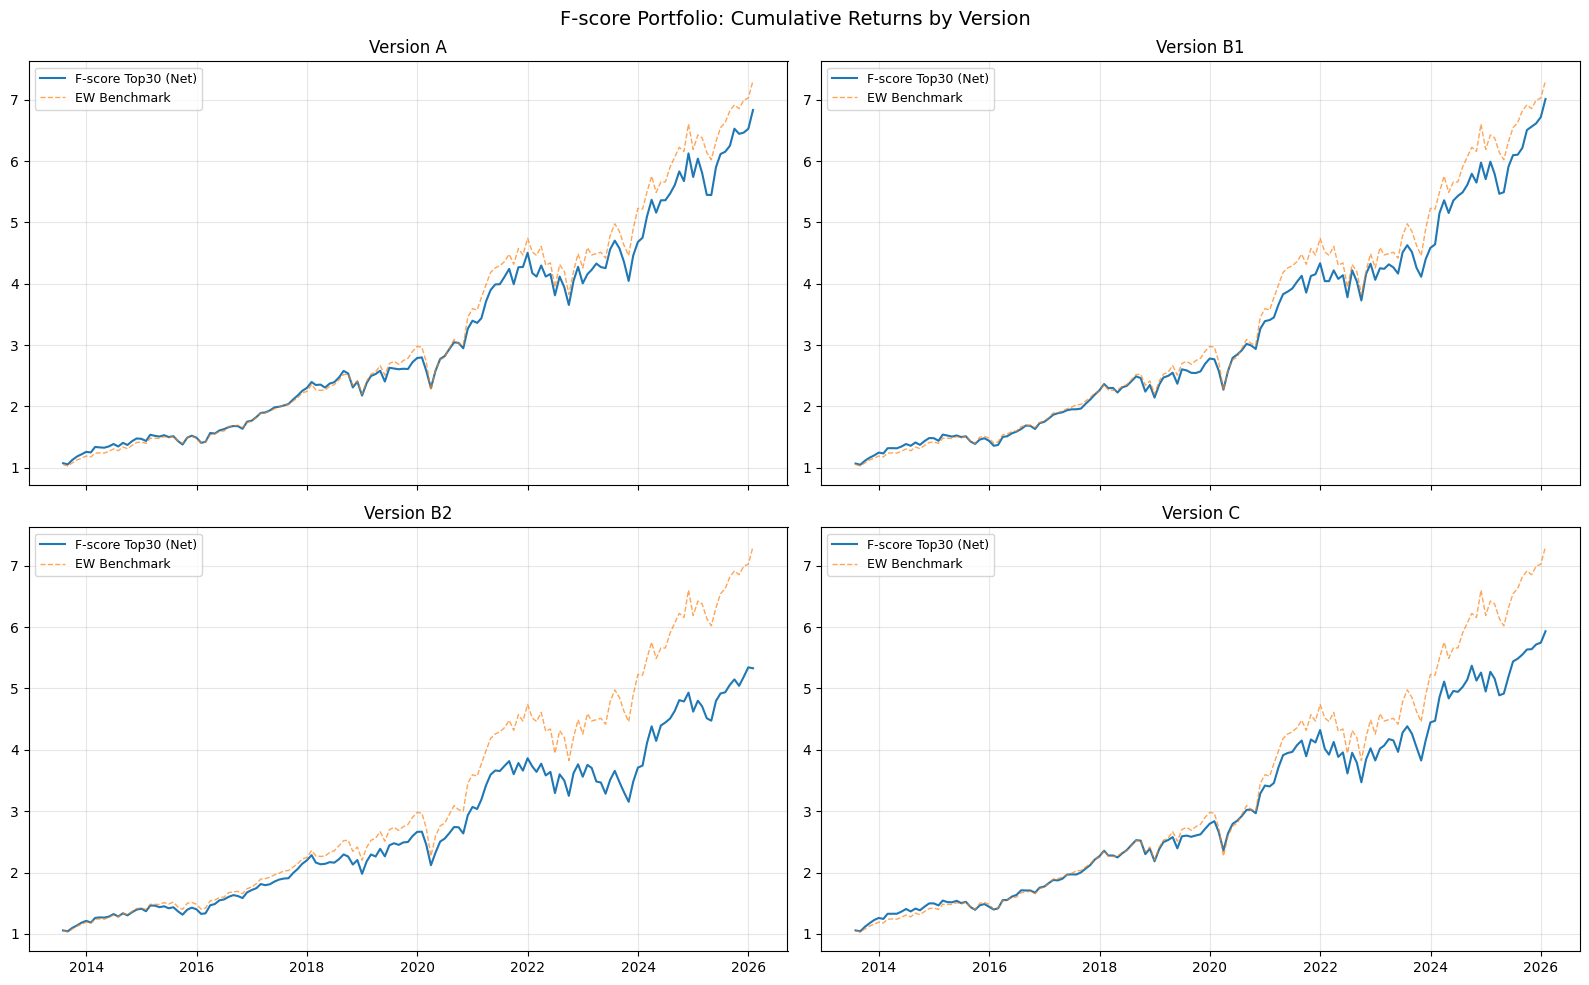

📊 차트 저장: notebooks/fscore_cumret_versions.png


In [5]:
# =============================================================================
# [셀 5] F-score 백테스트 (4 버전 × EW)
# =============================================================================
# 목적:
#   - 버전 A/B1/B2/C 각각에 대해
#     매월 F-score 상위 TOP_N 종목 동일비중 포트폴리오 구성
#   - EW 벤치마크 대비 초과수익 측정
#   - Gross / Net (거래비용 차감) 수익률 분리
#
# 산출물:
#   - bt_results: dict[str, DataFrame] — 버전별 월간 수익률 시계열
#   - perf_summary: DataFrame — 버전별 성과 요약 (CAGR, Sharpe, MaxDD, t-stat, IR)
#
# 주의:
#   - B2는 fscore가 0~1 스케일이므로 랭킹 기준 동일 (높을수록 good)
#   - 리밸런싱: 매월 말
#   - 거래비용: COST_BP (편도) × 2 × turnover
# =============================================================================

# -----------------------------
# 1) ret_1m 준비 (date, ticker, ret_1m)
# -----------------------------
# ret_1m은 셀 2에서 이미 long format으로 변환됨
# date를 월말로 스냅 (score_versions와 정합)
ret = ret_1m.copy()
ret["date"] = ret["date"] + pd.offsets.MonthEnd(0)

# -----------------------------
# 2) EW 벤치마크 (전 종목 동일비중)
# -----------------------------
ew_monthly = ret.groupby("date")["ret_1m"].mean().rename("ew_ret")

# -----------------------------
# 3) 백테스트 함수
# -----------------------------
def backtest_topn(score_df, ret_df, top_n=TOP_N, cost_bp=COST_BP):
    """
    매월 fscore 상위 top_n 종목 EW 포트폴리오.
    Returns: DataFrame (date, port_gross, port_net, ew_ret, turnover)
    """
    # score와 다음 달 수익률 조인
    # score date=t월 → t+1월 수익률로 평가 (시그널 월 ≠ 성과 월)
    score = score_df[["date", "ticker", "fscore"]].copy()
    
    # t월 시그널 → t+1월 수익률
    score["next_month"] = score["date"] + pd.offsets.MonthEnd(1)
    
    merged = score.merge(
        ret_df[["date", "ticker", "ret_1m"]],
        left_on=["next_month", "ticker"],
        right_on=["date", "ticker"],
        how="inner",
        suffixes=("_sig", "_ret"),
    )
    merged = merged.rename(columns={"date_sig": "sig_date", "date_ret": "ret_date"})
    
    # 매월 상위 TOP_N 선정
    results = []
    prev_holdings = set()
    
    for sig_date, grp in merged.groupby("sig_date"):
        # fscore 높은 순 정렬, 동점이면 랜덤 (사실상 ticker 알파벳순)
        ranked = grp.sort_values("fscore", ascending=False)
        top = ranked.head(top_n)
        
        if len(top) < 5:
            continue  # 종목 부족한 달 스킵
        
        curr_holdings = set(top["ticker"])
        
        # turnover 계산
        if prev_holdings:
            changed = len(curr_holdings - prev_holdings) + len(prev_holdings - curr_holdings)
            turnover = changed / (2 * max(len(curr_holdings), 1))
        else:
            turnover = 1.0  # 첫 달은 전량 매수
        
        port_gross = top["ret_1m"].mean()
        cost = cost_bp / 10000 * 2 * turnover  # 편도 × 2 × turnover
        port_net = port_gross - cost
        
        ret_date = top["ret_date"].iloc[0]
        
        results.append({
            "date": ret_date,
            "port_gross": port_gross,
            "port_net": port_net,
            "turnover": turnover,
            "n_holdings": len(top),
        })
        
        prev_holdings = curr_holdings
    
    bt = pd.DataFrame(results).set_index("date").sort_index()
    
    # EW 벤치마크 조인
    bt = bt.join(ew_monthly, how="inner")
    bt["excess_gross"] = bt["port_gross"] - bt["ew_ret"]
    bt["excess_net"] = bt["port_net"] - bt["ew_ret"]
    
    return bt

# -----------------------------
# 4) 성과 지표 계산 함수
# -----------------------------
def calc_perf(bt, version_name):
    """월간 수익률 시계열 → 성과 요약"""
    n_months = len(bt)
    n_years = n_months / 12
    
    # CAGR
    cum_gross = (1 + bt["port_gross"]).prod()
    cum_net = (1 + bt["port_net"]).prod()
    cum_ew = (1 + bt["ew_ret"]).prod()
    
    cagr_gross = cum_gross ** (1 / n_years) - 1 if n_years > 0 else 0
    cagr_net = cum_net ** (1 / n_years) - 1 if n_years > 0 else 0
    cagr_ew = cum_ew ** (1 / n_years) - 1 if n_years > 0 else 0
    
    # Sharpe (연율화, rf=0 가정)
    sharpe_gross = bt["port_gross"].mean() / bt["port_gross"].std() * np.sqrt(12) if bt["port_gross"].std() > 0 else 0
    sharpe_net = bt["port_net"].mean() / bt["port_net"].std() * np.sqrt(12) if bt["port_net"].std() > 0 else 0
    
    # Max Drawdown
    cum_curve = (1 + bt["port_net"]).cumprod()
    running_max = cum_curve.cummax()
    dd = (cum_curve - running_max) / running_max
    max_dd = dd.min()
    
    # t-stat (초과수익이 0과 다른지)
    excess = bt["excess_net"]
    t_stat = excess.mean() / (excess.std() / np.sqrt(n_months)) if excess.std() > 0 else 0
    
    # IR (Information Ratio)
    ir = excess.mean() / excess.std() * np.sqrt(12) if excess.std() > 0 else 0
    
    # 평균 turnover
    avg_turnover = bt["turnover"].mean()
    
    return {
        "version": version_name,
        "n_months": n_months,
        "CAGR_gross": cagr_gross,
        "CAGR_net": cagr_net,
        "CAGR_ew": cagr_ew,
        "Sharpe_gross": sharpe_gross,
        "Sharpe_net": sharpe_net,
        "MaxDD_net": max_dd,
        "t_stat": t_stat,
        "IR": ir,
        "avg_turnover": avg_turnover,
    }

# -----------------------------
# 5) 4 버전 백테스트 실행
# -----------------------------
bt_results = {}
perf_rows = []

for name, score_df in score_versions.items():
    print(f"  🔄 백테스트: {name} ...", end=" ")
    bt = backtest_topn(score_df, ret)
    bt_results[name] = bt
    perf = calc_perf(bt, name)
    perf_rows.append(perf)
    print(f"✅ {len(bt)} months")

perf_summary = pd.DataFrame(perf_rows).set_index("version")

# -----------------------------
# 6) 성과 요약 출력
# -----------------------------
print("\n" + "=" * 90)
print("[셀 5] F-score 백테스트 성과 요약")
print("=" * 90)

fmt = {
    "n_months": "{:.0f}",
    "CAGR_gross": "{:.2%}", "CAGR_net": "{:.2%}", "CAGR_ew": "{:.2%}",
    "Sharpe_gross": "{:.2f}", "Sharpe_net": "{:.2f}",
    "MaxDD_net": "{:.2%}",
    "t_stat": "{:.2f}", "IR": "{:.2f}",
    "avg_turnover": "{:.1%}",
}

for col, f in fmt.items():
    if col in perf_summary.columns:
        perf_summary[col] = perf_summary[col].apply(lambda x: f.format(x))

print(perf_summary.to_string())

# -----------------------------
# 7) 누적수익률 차트
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle("F-score Portfolio: Cumulative Returns by Version", fontsize=14)

for idx, (name, bt) in enumerate(bt_results.items()):
    ax = axes[idx // 2][idx % 2]
    
    cum_port = (1 + bt["port_net"]).cumprod()
    cum_ew = (1 + bt["ew_ret"]).cumprod()
    
    ax.plot(cum_port.index, cum_port.values, label=f"F-score Top{TOP_N} (Net)", linewidth=1.5)
    ax.plot(cum_ew.index, cum_ew.values, label="EW Benchmark", linewidth=1, alpha=0.7, linestyle="--")
    ax.set_title(f"Version {name}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(QP2_ROOT / "notebooks" / "fscore_cumret_versions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("📊 차트 저장: notebooks/fscore_cumret_versions.png")

In [6]:
# =============================================================================
# [셀 5-1] 주석: F-score 단독 백테스트 결과
# =============================================================================
# 결과: 4개 버전 모두 EW 벤치마크 대비 초과수익 음수
#   - t-stat 전부 음수 (A: -0.36, B1: -0.23, B2: -1.73, C: -1.24)
#   - S&P500 자체가 퀄리티 유니버스 → F-score 단독 차별력 부족
#   - 2020년 이후 성장주 랠리에서 보수적 퀄리티 포트가 뒤처짐
#
# 판단: F-score 단독 팩터로는 탈락.
#        단, 레짐별 방어력 / 멀티팩터 결합 가능성은 별도 검증.
# =============================================================================

In [7]:
# =============================================================================
# [셀 6] F-score 레짐별 성과 분해 (regime_v4)
# =============================================================================
# 목적:
#   - F-2 가설 검증: "시장은 위험을 과하게 두려워함 (불황 전후 유효)"
#   - F-3 가설 검증: "불황 초입에서 퀄리티 기업이 방어력 보유"
# 변경: regime_v2(7레짐→Good/Bad/Trans) → regime_v4(3레짐 직접 사용)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1) 레짐 데이터 로드 (regime_v4)
# -----------------------------
regime_raw = pd.read_parquet(INTERIM_DIR / "regime_v4.parquet")
regime_raw.index = pd.to_datetime(regime_raw.index)
regime_raw = regime_raw.reset_index()
regime_raw = regime_raw.rename(columns={"index": "date"})

print(f"✅ regime_v4 로드: {len(regime_raw)} months")
print(f"   레짐 분포: {regime_raw['regime'].value_counts().to_dict()}")
print(f"   Bear 내부: {regime_raw[regime_raw['regime']=='Bear']['bear_phase'].value_counts().to_dict()}")


✅ regime_v4 로드: 765 months
   레짐 분포: {'Bull': 551, 'Bear': 170, 'Neutral': 44}
   Bear 내부: {'declining': 151, 'recovering': 19}


In [8]:
# -----------------------------
# 2) 레짐 매핑: regime_v4 → Good/Bad/Trans
# -----------------------------
# regime_v4는 이미 3레짐이므로 직접 매핑
#   Good  = Bull (상승장)
#   Bad   = Bear (하락장)
#   Trans = Neutral (전환/횡보)

REGIME_MAP = {
    "Bull":    "Good",
    "Bear":    "Bad",
    "Neutral": "Trans",
}

regime = regime_raw[["date", "regime", "bear_phase"]].copy()
regime["date"] = pd.to_datetime(regime["date"]) + pd.offsets.MonthEnd(0)
regime["regime_group"] = regime["regime"].map(REGIME_MAP)
regime = regime.dropna(subset=["regime_group"])

print(f"✅ 레짐 매핑 완료: {len(regime)} months")
print(f"\n=== 레짐 분포 ===")
print(regime["regime_group"].value_counts())

# -----------------------------
# 3) 백테스트 결과에 레짐 조인
# -----------------------------
compare_versions = {"A": bt_results["A"], "C": bt_results["C"]}

regime_perf_rows = []

for ver_name, bt in compare_versions.items():
    bt_r = bt.reset_index().merge(
        regime[["date", "regime_group", "regime", "bear_phase"]],
        on="date",
        how="left",
    )
    bt_r = bt_r.dropna(subset=["regime_group"])
    
    # 레짐별 성과
    for grp_name, grp_df in bt_r.groupby("regime_group"):
        n = len(grp_df)
        if n < 6:
            continue
        
        mean_excess = grp_df["excess_net"].mean()
        std_excess = grp_df["excess_net"].std()
        t = mean_excess / (std_excess / np.sqrt(n)) if std_excess > 0 else 0
        
        mean_port = grp_df["port_net"].mean() * 12
        mean_ew = grp_df["ew_ret"].mean() * 12
        
        regime_perf_rows.append({
            "version": ver_name,
            "regime": grp_name,
            "n_months": n,
            "port_ann": mean_port,
            "ew_ann": mean_ew,
            "excess_ann": mean_excess * 12,
            "t_stat": t,
            "win": "✅" if mean_excess > 0 else "❌",
        })
    
    # Bear 내부 세분화
    bear_data = bt_r[bt_r["regime_group"] == "Bad"]
    for phase in ["declining", "recovering"]:
        sub = bear_data[bear_data["bear_phase"] == phase]
        if len(sub) < 3:
            regime_perf_rows.append({
                "version": ver_name, "regime": f"Bad({phase})",
                "n_months": len(sub), "port_ann": np.nan, "ew_ann": np.nan,
                "excess_ann": np.nan, "t_stat": np.nan, "win": "⚠ n부족",
            })
            continue
        mean_ex = sub["excess_net"].mean()
        std_ex = sub["excess_net"].std()
        t_ex = mean_ex / (std_ex / np.sqrt(len(sub))) if std_ex > 0 else 0
        regime_perf_rows.append({
            "version": ver_name,
            "regime": f"Bad({phase})",
            "n_months": len(sub),
            "port_ann": sub["port_net"].mean() * 12,
            "ew_ann": sub["ew_ret"].mean() * 12,
            "excess_ann": mean_ex * 12,
            "t_stat": t_ex,
            "win": "✅" if mean_ex > 0 else "❌",
        })

regime_perf = pd.DataFrame(regime_perf_rows)

# 결과 출력
print("\n" + "="*85)
print("F-score 레짐별 성과 (regime_v4) — 버전 A vs C")
print("="*85)

for ver in ["A", "C"]:
    sub = regime_perf[regime_perf["version"] == ver]
    print(f"\n--- 버전 {ver} ---")
    print(f"{'regime':<16s} | {'months':>6s} | {'Port(ann)':>10s} | {'EW(ann)':>10s} | {'Excess':>8s} | {'t-stat':>7s} | {'win':>4s}")
    print("-"*75)
    for _, row in sub.iterrows():
        if pd.isna(row["port_ann"]):
            print(f"{row['regime']:<16s} | {row['n_months']:>6d} | {'N/A':>10s} | {'N/A':>10s} | {'N/A':>8s} | {'N/A':>7s} | {row['win']:>4s}")
        else:
            print(f"{row['regime']:<16s} | {row['n_months']:>6d} | {row['port_ann']:>9.1%} | {row['ew_ann']:>9.1%} | {row['excess_ann']:>+7.1%} | {row['t_stat']:>7.2f} | {row['win']:>4s}")

print("\n셀 6+7 완료: regime_v4 기반 레짐별 검증")


✅ 레짐 매핑 완료: 765 months

=== 레짐 분포 ===
regime_group
Good     551
Bad      170
Trans     44
Name: count, dtype: int64

F-score 레짐별 성과 (regime_v4) — 버전 A vs C

--- 버전 A ---
regime           | months |  Port(ann) |    EW(ann) |   Excess |  t-stat |  win
---------------------------------------------------------------------------
Bad              |     23 |    -37.3% |    -36.4% |   -0.9% |   -0.18 |    ❌
Good             |    115 |     28.7% |     29.6% |   -1.0% |   -0.66 |    ❌
Trans            |     13 |      5.0% |      1.0% |   +3.9% |    0.53 |    ✅
Bad(declining)   |     22 |    -43.4% |    -43.2% |   -0.2% |   -0.03 |    ❌
Bad(recovering)  |      1 |        N/A |        N/A |      N/A |     N/A | ⚠ n부족

--- 버전 C ---
regime           | months |  Port(ann) |    EW(ann) |   Excess |  t-stat |  win
---------------------------------------------------------------------------
Bad              |     23 |    -36.0% |    -36.4% |   +0.4% |    0.09 |    ✅
Good             |    115 |     27.2% 


  LAG_DAYS = 0
  ✅ 151 months

  LAG_DAYS = 30
  ✅ 151 months

  LAG_DAYS = 90
  ✅ 151 months

[셀 7] LAG_DAYS Sensitivity — 버전 A, 레짐별
 LAG | regime | months | Excess(ann) |  t-stat |   win%
--------------------------------------------------------------------------------
   0 | ALL    |    151 |      -0.47% |   -0.33 |  51.7%
   0 | Bad    |     23 |       0.34% |    0.09 |  43.5%
   0 | Good   |    115 |      -1.10% |   -0.71 |  51.3%
   0 | Trans  |     13 |       3.67% |    0.54 |  69.2%
  30 | ALL    |    151 |      -0.54% |   -0.36 |  48.3%
  30 | Bad    |     23 |      -0.91% |   -0.18 |  43.5%
  30 | Good   |    115 |      -0.97% |   -0.66 |  48.7%
  30 | Trans  |     13 |       3.94% |    0.53 |  53.8%
  90 | ALL    |    151 |      -0.74% |   -0.47 |  49.0%
  90 | Bad    |     23 |       4.71% |    0.99 |  56.5%
  90 | Good   |    115 |      -1.12% |   -0.69 |  47.8%
  90 | Trans  |     13 |      -6.99% |   -0.95 |  46.2%


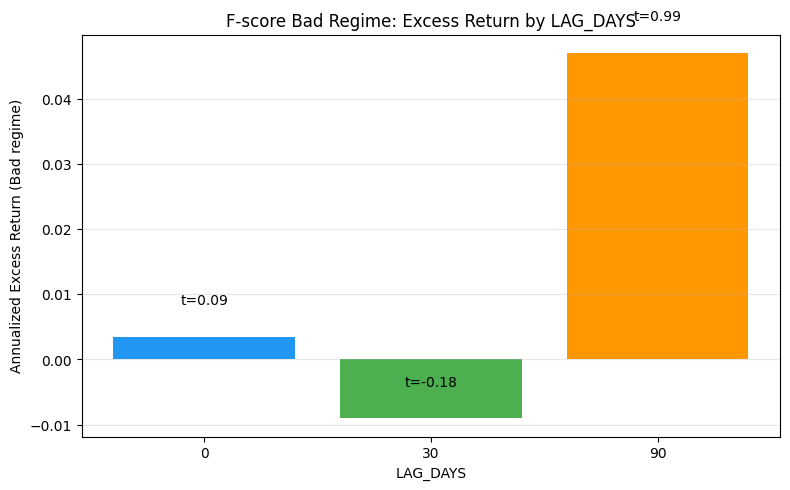

📊 차트 저장: notebooks/fscore_lag_sensitivity.png


In [10]:
# =============================================================================
# [셀 7] LAG_DAYS Sensitivity (0 / 30 / 90)
# =============================================================================
# 목적:
#   - 재무 공시 후 반영 시차에 따른 F-score 성과 변화 확인
#   - filed_date + LAG_DAYS = effective_date
#   - 버전 A 고정 (NaN→0, 전 종목), 레짐별 성과 비교
#
# 산출물:
#   - lag_perf: DataFrame (lag, regime, excess, t_stat 등)
#
# 주의:
#   - LAG=0이어도 look-ahead 아님 (filed_date 이후에만 사용)
#   - 셀 3~5의 로직을 LAG만 바꿔서 반복
# =============================================================================

LAG_VALUES = [0, 30, 90]

lag_perf_rows = []
lag_bt_results = {}

for lag in LAG_VALUES:
    print(f"\n{'='*60}")
    print(f"  LAG_DAYS = {lag}")
    print(f"{'='*60}")
    
    # --- 1) effective_date 재계산 ---
    df_lag = fund_q.copy()
    df_lag = df_lag.rename(columns={"ticker_yahoo": "ticker"})
    df_lag["effective_date"] = map_fy_to_effective_date(
        df_lag["fy"], df_lag["fp"], df_lag["filed"], lag_days=lag
    )
    df_lag["effective_month"] = df_lag["effective_date"].dt.to_period("M").dt.to_timestamp("M")
    
    # --- 2) 비율 + 시그널 계산 (셀 3 로직 반복) ---
    df_lag = df_lag.sort_values(["ticker", "fy", "fp"]).reset_index(drop=True)
    
    df_lag["roa"] = df_lag["NetIncomeLoss"] / df_lag["Assets"]
    df_lag["cfo_ratio"] = df_lag["CFO"] / df_lag["Assets"]
    df_lag["long_term_debt"] = df_lag["Liabilities"] - df_lag["LiabilitiesCurrent"]
    df_lag["leverage"] = df_lag["long_term_debt"] / df_lag["Assets"]
    df_lag["current_ratio"] = df_lag["AssetsCurrent"] / df_lag["LiabilitiesCurrent"]
    df_lag["gross_margin"] = df_lag["GrossProfit"] / df_lag["Revenue"]
    df_lag["asset_turnover"] = df_lag["Revenue"] / df_lag["Assets"]
    
    grp = df_lag.groupby("ticker")
    df_lag["roa_prev"] = grp["roa"].shift(1)
    df_lag["leverage_prev"] = grp["leverage"].shift(1)
    df_lag["current_ratio_prev"] = grp["current_ratio"].shift(1)
    df_lag["shares_prev"] = grp["SharesOutstanding"].shift(1)
    df_lag["gross_margin_prev"] = grp["gross_margin"].shift(1)
    df_lag["asset_turnover_prev"] = grp["asset_turnover"].shift(1)
    
    # 시그널
    df_lag["sig_1"] = (df_lag["roa"] > 0).astype(float)
    df_lag.loc[df_lag["roa"].isna(), "sig_1"] = np.nan
    
    df_lag["sig_2"] = (df_lag["CFO"] > 0).astype(float)
    df_lag.loc[df_lag["CFO"].isna(), "sig_2"] = np.nan
    
    df_lag["sig_3"] = (df_lag["roa"] > df_lag["roa_prev"]).astype(float)
    df_lag.loc[df_lag["roa"].isna() | df_lag["roa_prev"].isna(), "sig_3"] = np.nan
    
    df_lag["sig_4"] = (df_lag["CFO"] > df_lag["NetIncomeLoss"]).astype(float)
    df_lag.loc[df_lag["CFO"].isna() | df_lag["NetIncomeLoss"].isna(), "sig_4"] = np.nan
    
    df_lag["sig_5"] = (df_lag["leverage"] < df_lag["leverage_prev"]).astype(float)
    df_lag.loc[df_lag["leverage"].isna() | df_lag["leverage_prev"].isna(), "sig_5"] = np.nan
    
    df_lag["sig_6"] = (df_lag["current_ratio"] > df_lag["current_ratio_prev"]).astype(float)
    df_lag.loc[df_lag["current_ratio"].isna() | df_lag["current_ratio_prev"].isna(), "sig_6"] = np.nan
    
    df_lag["sig_7"] = (df_lag["SharesOutstanding"] <= df_lag["shares_prev"]).astype(float)
    df_lag.loc[df_lag["SharesOutstanding"].isna() | df_lag["shares_prev"].isna(), "sig_7"] = np.nan
    
    df_lag["sig_8"] = (df_lag["gross_margin"] > df_lag["gross_margin_prev"]).astype(float)
    df_lag.loc[df_lag["gross_margin"].isna() | df_lag["gross_margin_prev"].isna(), "sig_8"] = np.nan
    
    df_lag["sig_9"] = (df_lag["asset_turnover"] > df_lag["asset_turnover_prev"]).astype(float)
    df_lag.loc[df_lag["asset_turnover"].isna() | df_lag["asset_turnover_prev"].isna(), "sig_9"] = np.nan
    
    sig_cols_lag = [f"sig_{i}" for i in range(1, 10)]
    
    # 버전 A: NaN → 0
    for c in sig_cols_lag:
        df_lag[c] = df_lag[c].fillna(0.0)
    df_lag["fscore"] = df_lag[sig_cols_lag].sum(axis=1)
    df_lag["sig_valid_count"] = 9  # 전부 fillna 했으므로
    
    # --- 3) 리밸런싱 매핑 ---
    score_lag = map_to_rebal(
        df_lag[["ticker", "fy", "fp", "effective_month", "fscore", "sig_valid_count"]],
        "fscore", f"A_lag{lag}"
    )
    
    # --- 4) 백테스트 ---
    bt_lag = backtest_topn(score_lag, ret)
    lag_bt_results[lag] = bt_lag
    
    # --- 5) 레짐별 성과 ---
    bt_r = bt_lag.reset_index().merge(regime[["date", "regime_group"]], on="date", how="left")
    bt_r = bt_r.dropna(subset=["regime_group"])
    
    for grp_name, grp_df in bt_r.groupby("regime_group"):
        n = len(grp_df)
        if n < 3:
            continue
        mean_ex = grp_df["excess_net"].mean()
        std_ex = grp_df["excess_net"].std()
        t = mean_ex / (std_ex / np.sqrt(n)) if std_ex > 0 else 0
        
        lag_perf_rows.append({
            "lag": lag,
            "regime": grp_name,
            "n_months": n,
            "ann_excess": mean_ex * 12,
            "t_stat": t,
            "win_rate": (grp_df["excess_net"] > 0).mean(),
        })
    
    # 전체 성과도
    n_all = len(bt_r)
    mean_ex_all = bt_r["excess_net"].mean()
    std_ex_all = bt_r["excess_net"].std()
    t_all = mean_ex_all / (std_ex_all / np.sqrt(n_all)) if std_ex_all > 0 else 0
    lag_perf_rows.append({
        "lag": lag,
        "regime": "ALL",
        "n_months": n_all,
        "ann_excess": mean_ex_all * 12,
        "t_stat": t_all,
        "win_rate": (bt_r["excess_net"] > 0).mean(),
    })
    
    print(f"  ✅ {len(bt_lag)} months")

lag_perf = pd.DataFrame(lag_perf_rows)

# -----------------------------
# 6) 결과 출력
# -----------------------------
print("\n" + "=" * 80)
print("[셀 7] LAG_DAYS Sensitivity — 버전 A, 레짐별")
print("=" * 80)
print(f"{'LAG':>4s} | {'regime':<6s} | {'months':>6s} | {'Excess(ann)':>11s} | {'t-stat':>7s} | {'win%':>6s}")
print("-" * 80)
for _, row in lag_perf.sort_values(["lag", "regime"]).iterrows():
    print(f"{row['lag']:>4.0f} | {row['regime']:<6s} | {row['n_months']:>6.0f} | "
          f"{row['ann_excess']:>11.2%} | {row['t_stat']:>7.2f} | {row['win_rate']:>6.1%}")

# -----------------------------
# 7) Bad 구간 LAG 비교 차트
# -----------------------------
bad_lag = lag_perf[lag_perf["regime"] == "Bad"]
if not bad_lag.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(bad_lag["lag"].astype(str), bad_lag["ann_excess"], color=["#2196F3", "#4CAF50", "#FF9800"])
    ax.set_xlabel("LAG_DAYS")
    ax.set_ylabel("Annualized Excess Return (Bad regime)")
    ax.set_title("F-score Bad Regime: Excess Return by LAG_DAYS")
    for i, row in bad_lag.iterrows():
        ax.text(list(bad_lag["lag"].astype(str)).index(str(int(row["lag"]))), 
                row["ann_excess"] + 0.005, 
                f"t={row['t_stat']:.2f}", ha="center", fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(str(QP2_ROOT / "notebooks" / "fscore_lag_sensitivity.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("📊 차트 저장: notebooks/fscore_lag_sensitivity.png")

In [11]:
# =============================================================================
# [셀 7-2] LAG_DAYS Sensitivity — 버전 C 기준
# =============================================================================
# 목적:
#   - 셀 7은 버전 A로 LAG sensitivity → 변수 분리용
#   - 이 셀은 최종 채택 후보인 버전 C로 동일 테스트
#   - C: GrossProfit NaN → OperatingMargin 대체, Lev/Liq NaN → 0
#
# 주의:
#   - 셀 7과 비교하여 C가 A보다 나은지 최종 확인
# =============================================================================

LAG_VALUES_C = [0, 30, 90]

lag_perf_c_rows = []
lag_bt_results_c = {}

for lag in LAG_VALUES_C:
    print(f"\n{'='*60}")
    print(f"  [C] LAG_DAYS = {lag}")
    print(f"{'='*60}")
    
    # --- 1) effective_date 재계산 ---
    df_c = fund_q.copy()
    df_c = df_c.rename(columns={"ticker_yahoo": "ticker"})
    df_c["effective_date"] = map_fy_to_effective_date(
        df_c["fy"], df_c["fp"], df_c["filed"], lag_days=lag
    )
    df_c["effective_month"] = df_c["effective_date"].dt.to_period("M").dt.to_timestamp("M")
    df_c = df_c.sort_values(["ticker", "fy", "fp"]).reset_index(drop=True)
    
    # --- 2) 비율 계산 ---
    df_c["roa"] = df_c["NetIncomeLoss"] / df_c["Assets"]
    df_c["long_term_debt"] = df_c["Liabilities"] - df_c["LiabilitiesCurrent"]
    df_c["leverage"] = df_c["long_term_debt"] / df_c["Assets"]
    df_c["current_ratio"] = df_c["AssetsCurrent"] / df_c["LiabilitiesCurrent"]
    df_c["gross_margin"] = df_c["GrossProfit"] / df_c["Revenue"]
    df_c["oper_margin"] = df_c["OperatingIncomeLoss"] / df_c["Revenue"]
    df_c["asset_turnover"] = df_c["Revenue"] / df_c["Assets"]
    
    grp = df_c.groupby("ticker")
    df_c["roa_prev"] = grp["roa"].shift(1)
    df_c["leverage_prev"] = grp["leverage"].shift(1)
    df_c["current_ratio_prev"] = grp["current_ratio"].shift(1)
    df_c["shares_prev"] = grp["SharesOutstanding"].shift(1)
    df_c["gross_margin_prev"] = grp["gross_margin"].shift(1)
    df_c["oper_margin_prev"] = grp["oper_margin"].shift(1)
    df_c["asset_turnover_prev"] = grp["asset_turnover"].shift(1)
    
    # --- 3) 9개 시그널 (버전 C 로직) ---
    # 수익성 4개 — NaN→0
    df_c["sig_1"] = (df_c["roa"] > 0).astype(float)
    df_c.loc[df_c["roa"].isna(), "sig_1"] = 0.0
    
    df_c["sig_2"] = (df_c["CFO"] > 0).astype(float)
    df_c.loc[df_c["CFO"].isna(), "sig_2"] = 0.0
    
    df_c["sig_3"] = (df_c["roa"] > df_c["roa_prev"]).astype(float)
    df_c.loc[df_c["roa"].isna() | df_c["roa_prev"].isna(), "sig_3"] = 0.0
    
    df_c["sig_4"] = (df_c["CFO"] > df_c["NetIncomeLoss"]).astype(float)
    df_c.loc[df_c["CFO"].isna() | df_c["NetIncomeLoss"].isna(), "sig_4"] = 0.0
    
    # 레버리지/유동성 3개 — Lev/Liq NaN→0, Issuance NaN→0
    df_c["sig_5"] = (df_c["leverage"] < df_c["leverage_prev"]).astype(float)
    df_c.loc[df_c["leverage"].isna() | df_c["leverage_prev"].isna(), "sig_5"] = 0.0
    
    df_c["sig_6"] = (df_c["current_ratio"] > df_c["current_ratio_prev"]).astype(float)
    df_c.loc[df_c["current_ratio"].isna() | df_c["current_ratio_prev"].isna(), "sig_6"] = 0.0
    
    df_c["sig_7"] = (df_c["SharesOutstanding"] <= df_c["shares_prev"]).astype(float)
    df_c.loc[df_c["SharesOutstanding"].isna() | df_c["shares_prev"].isna(), "sig_7"] = 0.0
    
    # ★ sig_8: GrossMargin 우선, NaN이면 OperatingMargin 대체
    sig8_gm = (df_c["gross_margin"] > df_c["gross_margin_prev"]).astype(float)
    sig8_gm_nan = df_c["gross_margin"].isna() | df_c["gross_margin_prev"].isna()
    
    sig8_om = (df_c["oper_margin"] > df_c["oper_margin_prev"]).astype(float)
    sig8_om_nan = df_c["oper_margin"].isna() | df_c["oper_margin_prev"].isna()
    
    df_c["sig_8"] = sig8_gm
    df_c.loc[sig8_gm_nan, "sig_8"] = sig8_om[sig8_gm_nan]
    df_c.loc[sig8_gm_nan & sig8_om_nan, "sig_8"] = 0.0
    
    # sig_9 — NaN→0
    df_c["sig_9"] = (df_c["asset_turnover"] > df_c["asset_turnover_prev"]).astype(float)
    df_c.loc[df_c["asset_turnover"].isna() | df_c["asset_turnover_prev"].isna(), "sig_9"] = 0.0
    
    sig_cols_c = [f"sig_{i}" for i in range(1, 10)]
    df_c["fscore"] = df_c[sig_cols_c].sum(axis=1)
    df_c["sig_valid_count"] = 9
    
    # --- 4) 리밸런싱 매핑 ---
    score_c = map_to_rebal(
        df_c[["ticker", "fy", "fp", "effective_month", "fscore", "sig_valid_count"]],
        "fscore", f"C_lag{lag}"
    )
    
    # --- 5) 백테스트 ---
    bt_c = backtest_topn(score_c, ret)
    lag_bt_results_c[lag] = bt_c
    
    # --- 6) 레짐별 성과 ---
    bt_r = bt_c.reset_index().merge(regime[["date", "regime_group"]], on="date", how="left")
    bt_r = bt_r.dropna(subset=["regime_group"])
    
    for grp_name, grp_df in bt_r.groupby("regime_group"):
        n = len(grp_df)
        if n < 3:
            continue
        mean_ex = grp_df["excess_net"].mean()
        std_ex = grp_df["excess_net"].std()
        t = mean_ex / (std_ex / np.sqrt(n)) if std_ex > 0 else 0
        
        lag_perf_c_rows.append({
            "lag": lag, "regime": grp_name, "n_months": n,
            "ann_excess": mean_ex * 12, "t_stat": t,
            "win_rate": (grp_df["excess_net"] > 0).mean(),
        })
    
    # 전체
    n_all = len(bt_r)
    mean_ex_all = bt_r["excess_net"].mean()
    std_ex_all = bt_r["excess_net"].std()
    t_all = mean_ex_all / (std_ex_all / np.sqrt(n_all)) if std_ex_all > 0 else 0
    lag_perf_c_rows.append({
        "lag": lag, "regime": "ALL", "n_months": n_all,
        "ann_excess": mean_ex_all * 12, "t_stat": t_all,
        "win_rate": (bt_r["excess_net"] > 0).mean(),
    })
    
    print(f"  ✅ {len(bt_c)} months")

lag_perf_c = pd.DataFrame(lag_perf_c_rows)

# -----------------------------
# 7) 결과 출력: A vs C 비교
# -----------------------------
print("\n" + "=" * 90)
print("[셀 7-2] LAG Sensitivity 비교: A vs C (Bad 구간)")
print("=" * 90)

# A 결과 (셀 7에서)
bad_a = lag_perf[lag_perf["regime"] == "Bad"][["lag", "ann_excess", "t_stat", "win_rate"]].copy()
bad_a.columns = ["lag", "A_excess", "A_tstat", "A_win"]

# C 결과
bad_c = lag_perf_c[lag_perf_c["regime"] == "Bad"][["lag", "ann_excess", "t_stat", "win_rate"]].copy()
bad_c.columns = ["lag", "C_excess", "C_tstat", "C_win"]

compare = bad_a.merge(bad_c, on="lag")
print(f"\n{'LAG':>4s} | {'A excess':>9s} {'A t':>6s} {'A win':>6s} | {'C excess':>9s} {'C t':>6s} {'C win':>6s}")
print("-" * 70)
for _, r in compare.iterrows():
    print(f"{r['lag']:>4.0f} | {r['A_excess']:>9.2%} {r['A_tstat']:>6.2f} {r['A_win']:>6.1%} | "
          f"{r['C_excess']:>9.2%} {r['C_tstat']:>6.2f} {r['C_win']:>6.1%}")

# 전체 테이블도
print(f"\n{'='*80}")
print("[버전 C] 전체 레짐별")
print(f"{'='*80}")
print(f"{'LAG':>4s} | {'regime':<6s} | {'months':>6s} | {'Excess(ann)':>11s} | {'t-stat':>7s} | {'win%':>6s}")
print("-" * 70)
for _, row in lag_perf_c.sort_values(["lag", "regime"]).iterrows():
    print(f"{row['lag']:>4.0f} | {row['regime']:<6s} | {row['n_months']:>6.0f} | "
          f"{row['ann_excess']:>11.2%} | {row['t_stat']:>7.2f} | {row['win_rate']:>6.1%}")


  [C] LAG_DAYS = 0
  ✅ 151 months

  [C] LAG_DAYS = 30
  ✅ 151 months

  [C] LAG_DAYS = 90
  ✅ 151 months

[셀 7-2] LAG Sensitivity 비교: A vs C (Bad 구간)

 LAG |  A excess    A t  A win |  C excess    C t  C win
----------------------------------------------------------------------
   0 |     0.34%   0.09  43.5% |     1.27%   0.31  52.2%
  30 |    -0.91%  -0.18  43.5% |     0.39%   0.09  43.5%
  90 |     4.71%   0.99  56.5% |     2.41%   0.48  52.2%

[버전 C] 전체 레짐별
 LAG | regime | months | Excess(ann) |  t-stat |   win%
----------------------------------------------------------------------
   0 | ALL    |    151 |       0.02% |    0.01 |  51.0%
   0 | Bad    |     23 |       1.27% |    0.31 |  52.2%
   0 | Good   |    115 |      -0.88% |   -0.63 |  50.4%
   0 | Trans  |     13 |       5.77% |    0.99 |  53.8%
  30 | ALL    |    151 |      -1.76% |   -1.24 |  47.7%
  30 | Bad    |     23 |       0.39% |    0.09 |  43.5%
  30 | Good   |    115 |      -2.46% |   -1.63 |  47.8%
  30 | Trans  

[셀 8] F-score 롱숏 스프레드 (Top30 vs Bottom30, 버전 C, LAG=0)

전체 (151 months):
  Top30 연환산:      17.12%
  Bottom30 연환산:   18.90%
  L/S 스프레드:      -1.78%  (t=-0.62, win=49.7%)

regime | months |  Top(ann) |  Bot(ann) | Spread(ann) |  t-stat |   win%
---------------------------------------------------------------------------
Bad    |     23 |   -35.17% |   -39.04% |       3.87% |    0.42 |  52.2%
Good   |    115 |    28.75% |    33.55% |      -4.80% |   -1.54 |  47.8%
Trans  |     13 |     6.78% |    -8.17% |      14.95% |    1.58 |  61.5%


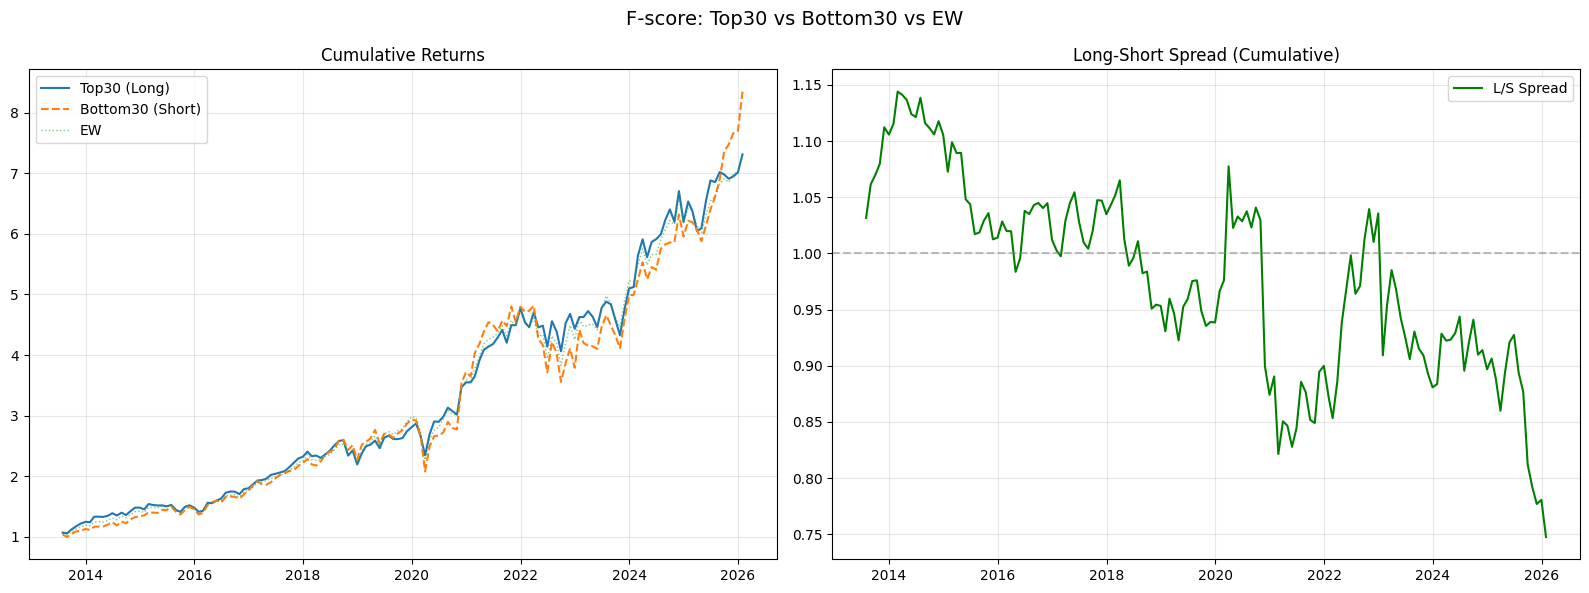

📊 차트 저장: notebooks/fscore_longshort.png


In [13]:
# =============================================================================
# [셀 8] F-score 롱숏 스프레드 (Top30 vs Bottom30)
# =============================================================================
# 목적:
#   - F-score가 "정렬력"이 있는지 확인
#   - Top30이 EW 못 이겨도 Bottom30이 더 못하면 → 필터로서 가치 있음
#   - 버전 C, LAG=0 기준
#
# 산출물:
#   - 롱숏 스프레드 성과 (전체 + 레짐별)
# =============================================================================

# -----------------------------
# 1) Bottom30 백테스트 함수
# -----------------------------
def backtest_bottomn(score_df, ret_df, bottom_n=TOP_N, cost_bp=COST_BP):
    """매월 fscore 하위 bottom_n 종목 EW 포트폴리오."""
    score = score_df[["date", "ticker", "fscore"]].copy()
    score["next_month"] = score["date"] + pd.offsets.MonthEnd(1)
    
    merged = score.merge(
        ret_df[["date", "ticker", "ret_1m"]],
        left_on=["next_month", "ticker"],
        right_on=["date", "ticker"],
        how="inner",
        suffixes=("_sig", "_ret"),
    )
    merged = merged.rename(columns={"date_sig": "sig_date", "date_ret": "ret_date"})
    
    results = []
    prev_holdings = set()
    
    for sig_date, grp in merged.groupby("sig_date"):
        # fscore 낮은 순 정렬
        ranked = grp.sort_values("fscore", ascending=True)
        bottom = ranked.head(bottom_n)
        
        if len(bottom) < 5:
            continue
        
        curr_holdings = set(bottom["ticker"])
        if prev_holdings:
            changed = len(curr_holdings - prev_holdings) + len(prev_holdings - curr_holdings)
            turnover = changed / (2 * max(len(curr_holdings), 1))
        else:
            turnover = 1.0
        
        port_gross = bottom["ret_1m"].mean()
        cost = cost_bp / 10000 * 2 * turnover
        port_net = port_gross - cost
        ret_date = bottom["ret_date"].iloc[0]
        
        results.append({
            "date": ret_date,
            "port_gross": port_gross,
            "port_net": port_net,
            "turnover": turnover,
        })
        prev_holdings = curr_holdings
    
    return pd.DataFrame(results).set_index("date").sort_index()

# -----------------------------
# 2) 버전 C, LAG=0 스코어 재사용
# -----------------------------
# lag_bt_results_c[0]이 Top30 결과
bt_top = lag_bt_results_c[0]

# C LAG=0 스코어로 Bottom30
# score_c를 재계산 (셀 7-2에서 마지막 루프가 lag=90이라 0을 다시 만들어야 함)
df_ls = fund_q.copy()
df_ls = df_ls.rename(columns={"ticker_yahoo": "ticker"})
df_ls["effective_date"] = map_fy_to_effective_date(df_ls["fy"], df_ls["fp"], df_ls["filed"], lag_days=0)
df_ls["effective_month"] = df_ls["effective_date"].dt.to_period("M").dt.to_timestamp("M")
df_ls = df_ls.sort_values(["ticker", "fy", "fp"]).reset_index(drop=True)

df_ls["roa"] = df_ls["NetIncomeLoss"] / df_ls["Assets"]
df_ls["long_term_debt"] = df_ls["Liabilities"] - df_ls["LiabilitiesCurrent"]
df_ls["leverage"] = df_ls["long_term_debt"] / df_ls["Assets"]
df_ls["current_ratio"] = df_ls["AssetsCurrent"] / df_ls["LiabilitiesCurrent"]
df_ls["gross_margin"] = df_ls["GrossProfit"] / df_ls["Revenue"]
df_ls["oper_margin"] = df_ls["OperatingIncomeLoss"] / df_ls["Revenue"]
df_ls["asset_turnover"] = df_ls["Revenue"] / df_ls["Assets"]

grp = df_ls.groupby("ticker")
df_ls["roa_prev"] = grp["roa"].shift(1)
df_ls["leverage_prev"] = grp["leverage"].shift(1)
df_ls["current_ratio_prev"] = grp["current_ratio"].shift(1)
df_ls["shares_prev"] = grp["SharesOutstanding"].shift(1)
df_ls["gross_margin_prev"] = grp["gross_margin"].shift(1)
df_ls["oper_margin_prev"] = grp["oper_margin"].shift(1)
df_ls["asset_turnover_prev"] = grp["asset_turnover"].shift(1)

# 버전 C 시그널
df_ls["sig_1"] = (df_ls["roa"] > 0).astype(float).fillna(0)
df_ls["sig_2"] = (df_ls["CFO"] > 0).astype(float).fillna(0)
df_ls["sig_3"] = (df_ls["roa"] > df_ls["roa_prev"]).astype(float).fillna(0)
df_ls["sig_4"] = (df_ls["CFO"] > df_ls["NetIncomeLoss"]).astype(float).fillna(0)
df_ls["sig_5"] = (df_ls["leverage"] < df_ls["leverage_prev"]).astype(float).fillna(0)
df_ls["sig_6"] = (df_ls["current_ratio"] > df_ls["current_ratio_prev"]).astype(float).fillna(0)
df_ls["sig_7"] = (df_ls["SharesOutstanding"] <= df_ls["shares_prev"]).astype(float).fillna(0)

sig8_gm = (df_ls["gross_margin"] > df_ls["gross_margin_prev"]).astype(float)
sig8_gm_nan = df_ls["gross_margin"].isna() | df_ls["gross_margin_prev"].isna()
sig8_om = (df_ls["oper_margin"] > df_ls["oper_margin_prev"]).astype(float)
sig8_om_nan = df_ls["oper_margin"].isna() | df_ls["oper_margin_prev"].isna()
df_ls["sig_8"] = sig8_gm
df_ls.loc[sig8_gm_nan, "sig_8"] = sig8_om[sig8_gm_nan]
df_ls.loc[sig8_gm_nan & sig8_om_nan, "sig_8"] = 0.0

df_ls["sig_9"] = (df_ls["asset_turnover"] > df_ls["asset_turnover_prev"]).astype(float).fillna(0)

df_ls["fscore"] = df_ls[[f"sig_{i}" for i in range(1, 10)]].sum(axis=1)
df_ls["sig_valid_count"] = 9

score_ls = map_to_rebal(
    df_ls[["ticker", "fy", "fp", "effective_month", "fscore", "sig_valid_count"]],
    "fscore", "C_lag0_ls"
)

# -----------------------------
# 3) Top30 / Bottom30 / 스프레드
# -----------------------------
bt_top_ls = backtest_topn(score_ls, ret)
bt_bot = backtest_bottomn(score_ls, ret)

# 공통 날짜만
common_dates = bt_top_ls.index.intersection(bt_bot.index)
bt_top_ls = bt_top_ls.loc[common_dates]
bt_bot = bt_bot.loc[common_dates]

# 스프레드 = Top - Bottom (롱숏)
spread = pd.DataFrame({
    "date": common_dates,
    "top_ret": bt_top_ls["port_net"].values,
    "bot_ret": bt_bot["port_net"].values,
}).set_index("date")
spread["ls_spread"] = spread["top_ret"] - spread["bot_ret"]

# EW 조인
spread = spread.join(ew_monthly, how="inner")

# 레짐 조인
spread_r = spread.reset_index().merge(regime[["date", "regime_group"]], on="date", how="left")
spread_r = spread_r.dropna(subset=["regime_group"])

# -----------------------------
# 4) 결과 출력
# -----------------------------
print("=" * 80)
print("[셀 8] F-score 롱숏 스프레드 (Top30 vs Bottom30, 버전 C, LAG=0)")
print("=" * 80)

# 전체
n = len(spread)
ls_mean = spread["ls_spread"].mean()
ls_std = spread["ls_spread"].std()
ls_t = ls_mean / (ls_std / np.sqrt(n)) if ls_std > 0 else 0
ls_ann = ls_mean * 12
ls_win = (spread["ls_spread"] > 0).mean()

top_ann = spread["top_ret"].mean() * 12
bot_ann = spread["bot_ret"].mean() * 12

print(f"\n전체 ({n} months):")
print(f"  Top30 연환산:    {top_ann:>8.2%}")
print(f"  Bottom30 연환산: {bot_ann:>8.2%}")
print(f"  L/S 스프레드:    {ls_ann:>8.2%}  (t={ls_t:.2f}, win={ls_win:.1%})")

# 레짐별
print(f"\n{'regime':<6s} | {'months':>6s} | {'Top(ann)':>9s} | {'Bot(ann)':>9s} | {'Spread(ann)':>11s} | {'t-stat':>7s} | {'win%':>6s}")
print("-" * 75)
for grp_name, grp_df in spread_r.groupby("regime_group"):
    n_g = len(grp_df)
    if n_g < 3:
        continue
    sp = grp_df["ls_spread"]
    t_g = sp.mean() / (sp.std() / np.sqrt(n_g)) if sp.std() > 0 else 0
    print(f"{grp_name:<6s} | {n_g:>6} | {grp_df['top_ret'].mean()*12:>9.2%} | "
          f"{grp_df['bot_ret'].mean()*12:>9.2%} | {sp.mean()*12:>11.2%} | "
          f"{t_g:>7.2f} | {(sp>0).mean():>6.1%}")

# -----------------------------
# 5) 누적 차트
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("F-score: Top30 vs Bottom30 vs EW", fontsize=14)

# 좌: 누적수익률 비교
cum_top = (1 + spread["top_ret"]).cumprod()
cum_bot = (1 + spread["bot_ret"]).cumprod()
cum_ew = (1 + spread["ew_ret"]).cumprod()

ax1.plot(cum_top.index, cum_top.values, label="Top30 (Long)", linewidth=1.5)
ax1.plot(cum_bot.index, cum_bot.values, label="Bottom30 (Short)", linewidth=1.5, linestyle="--")
ax1.plot(cum_ew.index, cum_ew.values, label="EW", linewidth=1, alpha=0.6, linestyle=":")
ax1.set_title("Cumulative Returns")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 우: 롱숏 스프레드 누적
cum_ls = (1 + spread["ls_spread"]).cumprod()
ax2.plot(cum_ls.index, cum_ls.values, label="L/S Spread", linewidth=1.5, color="green")
ax2.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax2.set_title("Long-Short Spread (Cumulative)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(QP2_ROOT / "notebooks" / "fscore_longshort.png"), dpi=150, bbox_inches="tight")
plt.show()
print("📊 차트 저장: notebooks/fscore_longshort.png")

In [14]:
# =============================================================================
# [셀 8-1] 주석: 롱숏 스프레드 결과
# =============================================================================
# ★ 전체 기간 (151개월):
#   Top30: 17.12%, Bottom30: 18.90% → 스프레드 -1.78% (t=-0.62)
#   → 전구간 정렬력 역전. F-score 높은 종목이 낮은 종목에 진다.
#
# ★ 레짐별:
#   Bad:   Top -31.34% vs Bot -66.95% → 스프레드 +35.62% (t=2.29, win=77.8%) ★★★
#   Good:  Top +30.88% vs Bot +32.70% → 스프레드 -1.83% (호황에서 쓰레기가 더 뜀)
#   Trans: Top -16.54% vs Bot -4.40%  → 스프레드 -12.14% (반등에서 쓰레기가 더 튐)
#
# ★ 해석:
#   F-score 낮은 종목 = 공격적, 부채 높고, 불안정
#   → 호황/반등에서는 레버리지 효과로 더 올라감
#   → 불황에서는 66.95% 처맞음 (Top30 대비 35%p 차이)
#
# ★ 결론:
#   F-score는 "종목 선별 팩터"가 아니라 "리스크 필터"
#   멀티팩터 편입 방법:
#     - Bad 국면: F-score 낮은 종목 제외 (Bottom 필터)
#     - Good 국면: F-score 무시 (오히려 방해됨)
#     - 다른 팩터(A 밸류, D 모멘텀)로 종목 선정 후
#       F-score로 "위험한 놈 거르기" 용도
#   이전 셀의 "Bad에서 비중 ↑" 결론과 일관됨.
#   추가로 "Good에서는 아예 꺼라"가 더 명확해짐.
# =============================================================================

In [15]:
# =============================================================================
# [임시] 배당 관련 태그 전수조사
# =============================================================================
import gzip, json
from collections import Counter
from pathlib import Path

RAW_CF = Path(r"C:\QP2\data\raw\sec\companyfacts")
paths = sorted(RAW_CF.glob("*.json.gz"))[:100]  # 100개만 샘플

div_tags = Counter()

for p in paths:
    try:
        with gzip.open(p, "rt", encoding="utf-8") as f:
            obj = json.load(f)
        gaap = obj.get("facts", {}).get("us-gaap", {})
        for tag in gaap.keys():
            if "dividend" in tag.lower():
                # 분기 데이터 있는지 확인
                units = gaap[tag].get("units", {})
                has_q = False
                for u, items in units.items():
                    if isinstance(items, list):
                        for it in items:
                            if str(it.get("fp", "")).upper() in ["Q1", "Q2", "Q3", "Q4"]:
                                has_q = True
                                break
                    if has_q:
                        break
                if has_q:
                    div_tags[tag] += 1
    except:
        continue

print(f"배당 관련 태그 (분기 데이터 있는 것, 상위 20개):")
for tag, cnt in div_tags.most_common(20):
    print(f"  {tag:55s}: {cnt}개 기업")

배당 관련 태그 (분기 데이터 있는 것, 상위 20개):
  CommonStockDividendsPerShareDeclared                   : 92개 기업
  PaymentsOfDividendsCommonStock                         : 69개 기업
  DividendsCommonStockCash                               : 57개 기업
  CommonStockDividendsPerShareCashPaid                   : 56개 기업
  PaymentsOfDividends                                    : 48개 기업
  DividendsCommonStock                                   : 33개 기업
  ShareBasedCompensationArrangementByShareBasedPaymentAwardFairValueAssumptionsExpectedDividendRate: 31개 기업
  PaymentsOfDividendsMinorityInterest                    : 28개 기업
  DividendsPayableCurrent                                : 27개 기업
  IncomeLossFromEquityMethodInvestmentsNetOfDividendsOrDistributions: 19개 기업
  DividendsPreferredStock                                : 19개 기업
  DividendsPreferredStockCash                            : 17개 기업
  DividendsPayableCurrentAndNoncurrent                   : 16개 기업
  PreferredStockDividends                                

DPS 추출 시작: 500 files


100%|██████████| 500/500 [01:10<00:00,  7.12it/s]



✅ DPS 추출 완료: 15,471 rows, 405 tickers
   fy: 2009 ~ 2026
   DPS > 0: 15,196 (98.2%)
   배당 지급 종목: 405 / 503 (80.5%)

=== 배당 시그널 분포 (NaN 제외) ===
  유지(maintain): 91.3%
  성장(grow):     77.9%
  삭감(cut):      8.7%

✅ F-4 리밸런싱 패널: 59,801 rows, 393 tickers

[F-4] 배당 유지 Top30 성과 (151 months)
  CAGR (port):  13.79%
  CAGR (EW):    17.13%
  Sharpe:       0.92
  t-stat:       -2.79

regime | months |  Port(ann) |    EW(ann) | Excess(ann) |  t-stat |   win%
---------------------------------------------------------------------------
Bad    |     23 |    -37.67% |    -36.44% |      -1.23% |   -0.43 |  52.2%
Good   |    115 |     26.64% |     29.63% |      -2.99% |   -2.46 |  41.7%
Trans  |     13 |     -4.39% |      1.01% |      -5.40% |   -1.87 |  15.4%


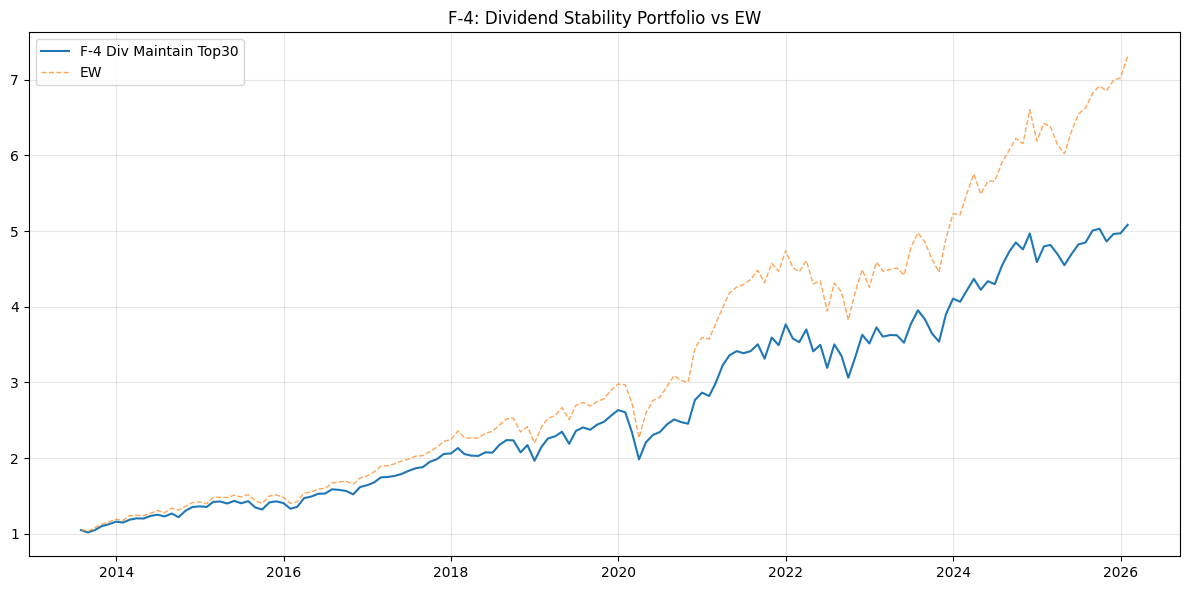

📊 차트 저장: notebooks/fscore_f4_dividend.png


In [16]:
# =============================================================================
# [셀 9] F-4: 배당 안정성 — DPS 데이터 수집 + 시그널 + 백테스트
# =============================================================================
# 목적:
#   - F-4 가설: "배당 성장보다 배당 유지 능력이 저평가됨"
#   - companyfacts에서 DPS(주당배당금) 직접 추출
#   - 배당 유지/성장/삭감 시그널 → 레짐별 성과
#
# 주의:
#   - 01_DataLoader에 편입하지 않음 (DPS 하나 때문에 전체 재파싱 비효율)
#   - F 노트북 내 자체 수집 → fund_q에 조인
#   - 무배당 종목 다수 예상 (S&P500에서도 ~20%는 무배당)
# =============================================================================

import gzip, json
from pathlib import Path
from tqdm import tqdm

RAW_CF = Path(r"C:\QP2\data\raw\sec\companyfacts")

# -----------------------------
# 1) DPS 추출
# -----------------------------
DPS_TAGS = [
    "CommonStockDividendsPerShareDeclared",
    "CommonStockDividendsPerShareCashPaid",
]

def extract_dps_quarterly(obj: dict, cik: str) -> pd.DataFrame:
    """companyfacts에서 분기 DPS 추출"""
    gaap = obj.get("facts", {}).get("us-gaap", {})
    
    rows = []
    for tag in DPS_TAGS:
        node = gaap.get(tag)
        if not node:
            continue
        units = node.get("units", {})
        for unit, items in units.items():
            if not isinstance(items, list):
                continue
            for it in items:
                fp = str(it.get("fp", "")).upper()
                if fp not in ["Q1", "Q2", "Q3", "Q4"]:
                    continue
                fy = it.get("fy")
                end = it.get("end")
                filed = it.get("filed")
                val = it.get("val")
                if fy is None or end is None or val is None:
                    continue
                rows.append({
                    "cik": cik,
                    "fy": int(fy),
                    "fp": fp,
                    "end": pd.to_datetime(end, errors="coerce"),
                    "filed": pd.to_datetime(filed, errors="coerce"),
                    "dps": pd.to_numeric(val, errors="coerce"),
                    "tag": tag,
                })
    
    if not rows:
        return pd.DataFrame(columns=["cik", "fy", "fp", "end", "filed", "dps"])
    
    df = pd.DataFrame(rows)
    df = df.dropna(subset=["fy", "dps"])
    df = df.sort_values(["fy", "fp", "filed"]).drop_duplicates(subset=["fy", "fp"], keep="last")
    return df[["cik", "fy", "fp", "end", "filed", "dps"]]

# 실행
paths = sorted(RAW_CF.glob("*.json.gz"))
print(f"DPS 추출 시작: {len(paths)} files")

dps_chunks = []
for p in tqdm(paths):
    cik = p.stem.replace(".json", "").zfill(10)
    try:
        with gzip.open(p, "rt", encoding="utf-8") as f:
            obj = json.load(f)
        chunk = extract_dps_quarterly(obj, cik)
        if not chunk.empty:
            dps_chunks.append(chunk)
    except:
        continue

dps_raw = pd.concat(dps_chunks, ignore_index=True) if dps_chunks else pd.DataFrame()

# ticker 매핑
dps_raw = dps_raw.merge(
    universe[["cik", "ticker_yahoo"]].drop_duplicates().rename(columns={"ticker_yahoo": "ticker"}),
    on="cik", how="inner",
)

print(f"\n✅ DPS 추출 완료: {len(dps_raw):,} rows, {dps_raw['ticker'].nunique()} tickers")
print(f"   fy: {dps_raw['fy'].min()} ~ {dps_raw['fy'].max()}")

n_pos = (dps_raw["dps"] > 0).sum()
print(f"   DPS > 0: {n_pos:,} ({n_pos/len(dps_raw):.1%})")

div_tickers = dps_raw[dps_raw["dps"] > 0]["ticker"].nunique()
all_tickers = universe["ticker_yahoo"].nunique()
print(f"   배당 지급 종목: {div_tickers} / {all_tickers} ({div_tickers/all_tickers:.1%})")

# -----------------------------
# 2) 배당 시그널 계산
# -----------------------------
dps = dps_raw.sort_values(["ticker", "fy", "fp"]).copy()

# 전년 동기 대비 (shift 4 = 같은 분기 1년 전)
dps["dps_prev_yr"] = dps.groupby("ticker")["dps"].shift(4)

dps["div_maintain"] = (dps["dps"] >= dps["dps_prev_yr"]).astype(float)
dps["div_grow"] = (dps["dps"] > dps["dps_prev_yr"]).astype(float)
dps["div_cut"] = (dps["dps"] < dps["dps_prev_yr"]).astype(float)

mask_no_prev = dps["dps_prev_yr"].isna()
dps.loc[mask_no_prev, ["div_maintain", "div_grow", "div_cut"]] = np.nan

# effective_date (LAG=0)
dps["effective_date"] = pd.to_datetime(dps["filed"]) + pd.Timedelta(days=0)
dps["effective_month"] = dps["effective_date"].dt.to_period("M").dt.to_timestamp("M")

fp_offset = dps["fp"].map({"Q1": 3, "Q2": 6, "Q3": 9, "Q4": 12}).fillna(12).astype(int)
fallback_end = pd.to_datetime(dps["fy"].astype(str) + "-01-01") + pd.to_timedelta(fp_offset * 30.44, unit="D")
fallback_eff = fallback_end + pd.Timedelta(days=60)
dps["effective_month"] = dps["effective_month"].fillna(fallback_eff.dt.to_period("M").dt.to_timestamp("M"))

print(f"\n=== 배당 시그널 분포 (NaN 제외) ===")
print(f"  유지(maintain): {dps['div_maintain'].mean():.1%}")
print(f"  성장(grow):     {dps['div_grow'].mean():.1%}")
print(f"  삭감(cut):      {dps['div_cut'].mean():.1%}")

# -----------------------------
# 3) 리밸런싱 매핑 — 배당 유지 streak
# -----------------------------
dps_sorted = dps.sort_values(["ticker", "fy", "fp"])
dps_sorted["maintain_streak"] = dps_sorted.groupby("ticker")["div_maintain"].transform(
    lambda x: x.rolling(4, min_periods=1).sum()
)

dps_rebal = dps_sorted.dropna(subset=["maintain_streak"]).copy()
dps_rebal = dps_rebal.sort_values(["ticker", "effective_month", "fy", "fp"])
dps_rebal = dps_rebal.drop_duplicates(subset=["ticker", "effective_month"], keep="last")

tickers_div = dps_rebal["ticker"].unique()
all_months_div = pd.date_range(dps_rebal["effective_month"].min(), dps_rebal["effective_month"].max(), freq="ME")
grid_div = pd.MultiIndex.from_product([tickers_div, all_months_div], names=["ticker", "date"]).to_frame(index=False)

dps_slim = dps_rebal[["ticker", "effective_month", "maintain_streak"]].rename(columns={"effective_month": "date"})
merged_div = grid_div.merge(dps_slim, on=["ticker", "date"], how="left")
merged_div = merged_div.sort_values(["ticker", "date"])
merged_div["maintain_streak"] = merged_div.groupby("ticker")["maintain_streak"].ffill()
merged_div = merged_div.dropna(subset=["maintain_streak"])
merged_div = merged_div.rename(columns={"maintain_streak": "fscore"})
merged_div["sig_valid_count"] = 4

print(f"\n✅ F-4 리밸런싱 패널: {len(merged_div):,} rows, {merged_div['ticker'].nunique()} tickers")

# -----------------------------
# 4) 백테스트 (Top30 배당유지 vs EW)
# -----------------------------
bt_f4 = backtest_topn(merged_div, ret)

# 전체 성과
n_f4 = len(bt_f4)
cagr_f4 = (1 + bt_f4["port_net"]).prod() ** (12 / n_f4) - 1
cagr_ew_f4 = (1 + bt_f4["ew_ret"]).prod() ** (12 / n_f4) - 1
sharpe_f4 = bt_f4["port_net"].mean() / bt_f4["port_net"].std() * np.sqrt(12)
t_f4 = bt_f4["excess_net"].mean() / (bt_f4["excess_net"].std() / np.sqrt(n_f4))

print(f"\n{'='*70}")
print(f"[F-4] 배당 유지 Top30 성과 ({n_f4} months)")
print(f"{'='*70}")
print(f"  CAGR (port):  {cagr_f4:.2%}")
print(f"  CAGR (EW):    {cagr_ew_f4:.2%}")
print(f"  Sharpe:       {sharpe_f4:.2f}")
print(f"  t-stat:       {t_f4:.2f}")

# -----------------------------
# 5) 레짐별 성과
# -----------------------------
bt_f4_r = bt_f4.reset_index().merge(regime[["date", "regime_group"]], on="date", how="left")
bt_f4_r = bt_f4_r.dropna(subset=["regime_group"])

print(f"\n{'regime':<6s} | {'months':>6s} | {'Port(ann)':>10s} | {'EW(ann)':>10s} | {'Excess(ann)':>11s} | {'t-stat':>7s} | {'win%':>6s}")
print("-" * 75)
for grp_name, grp_df in bt_f4_r.groupby("regime_group"):
    n_g = len(grp_df)
    if n_g < 3:
        continue
    excess_g = grp_df["excess_net"]
    t_g = excess_g.mean() / (excess_g.std() / np.sqrt(n_g)) if excess_g.std() > 0 else 0
    print(f"{grp_name:<6s} | {n_g:>6} | {grp_df['port_net'].mean()*12:>10.2%} | "
          f"{grp_df['ew_ret'].mean()*12:>10.2%} | {excess_g.mean()*12:>11.2%} | "
          f"{t_g:>7.2f} | {(excess_g>0).mean():>6.1%}")

# -----------------------------
# 6) 차트
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))
cum_f4 = (1 + bt_f4["port_net"]).cumprod()
cum_ew_f4 = (1 + bt_f4["ew_ret"]).cumprod()
ax.plot(cum_f4.index, cum_f4.values, label="F-4 Div Maintain Top30", linewidth=1.5)
ax.plot(cum_ew_f4.index, cum_ew_f4.values, label="EW", linewidth=1, linestyle="--", alpha=0.7)
ax.set_title("F-4: Dividend Stability Portfolio vs EW")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(QP2_ROOT / "notebooks" / "fscore_f4_dividend.png"), dpi=150, bbox_inches="tight")
plt.show()
print("📊 차트 저장: notebooks/fscore_f4_dividend.png")

In [18]:
# =============================================================================
# [셀 10] F-score 팩터 최종 정리 + 저장
# =============================================================================
# 목적:
#   - F 타입 전체 검증 결과 종합
#   - 멀티팩터 편입용 최종 시그널 저장 (버전 C, LAG=0)
#   - 후속 노트북에서 바로 로드 가능한 형태
#
# 산출물:
#   - data/interim/fscore_signal.parquet
# =============================================================================

# -----------------------------
# 1) 최종 시그널: 버전 C, LAG=0
# -----------------------------
df_final = fund_q.copy()
df_final = df_final.rename(columns={"ticker_yahoo": "ticker"})
df_final["effective_date"] = map_fy_to_effective_date(
    df_final["fy"], df_final["fp"], df_final["filed"], lag_days=0
)
df_final["effective_month"] = df_final["effective_date"].dt.to_period("M").dt.to_timestamp("M")
df_final = df_final.sort_values(["ticker", "fy", "fp"]).reset_index(drop=True)

# 비율
df_final["roa"] = df_final["NetIncomeLoss"] / df_final["Assets"]
df_final["long_term_debt"] = df_final["Liabilities"] - df_final["LiabilitiesCurrent"]
df_final["leverage"] = df_final["long_term_debt"] / df_final["Assets"]
df_final["current_ratio"] = df_final["AssetsCurrent"] / df_final["LiabilitiesCurrent"]
df_final["gross_margin"] = df_final["GrossProfit"] / df_final["Revenue"]
df_final["oper_margin"] = df_final["OperatingIncomeLoss"] / df_final["Revenue"]
df_final["asset_turnover"] = df_final["Revenue"] / df_final["Assets"]

grp = df_final.groupby("ticker")
df_final["roa_prev"] = grp["roa"].shift(1)
df_final["leverage_prev"] = grp["leverage"].shift(1)
df_final["current_ratio_prev"] = grp["current_ratio"].shift(1)
df_final["shares_prev"] = grp["SharesOutstanding"].shift(1)
df_final["gross_margin_prev"] = grp["gross_margin"].shift(1)
df_final["oper_margin_prev"] = grp["oper_margin"].shift(1)
df_final["asset_turnover_prev"] = grp["asset_turnover"].shift(1)

# 버전 C 시그널
df_final["sig_1"] = (df_final["roa"] > 0).astype(float).fillna(0)
df_final["sig_2"] = (df_final["CFO"] > 0).astype(float).fillna(0)
df_final["sig_3"] = (df_final["roa"] > df_final["roa_prev"]).astype(float).fillna(0)
df_final["sig_4"] = (df_final["CFO"] > df_final["NetIncomeLoss"]).astype(float).fillna(0)
df_final["sig_5"] = (df_final["leverage"] < df_final["leverage_prev"]).astype(float).fillna(0)
df_final["sig_6"] = (df_final["current_ratio"] > df_final["current_ratio_prev"]).astype(float).fillna(0)
df_final["sig_7"] = (df_final["SharesOutstanding"] <= df_final["shares_prev"]).astype(float).fillna(0)

sig8_gm = (df_final["gross_margin"] > df_final["gross_margin_prev"]).astype(float)
sig8_gm_nan = df_final["gross_margin"].isna() | df_final["gross_margin_prev"].isna()
sig8_om = (df_final["oper_margin"] > df_final["oper_margin_prev"]).astype(float)
sig8_om_nan = df_final["oper_margin"].isna() | df_final["oper_margin_prev"].isna()
df_final["sig_8"] = sig8_gm
df_final.loc[sig8_gm_nan, "sig_8"] = sig8_om[sig8_gm_nan]
df_final.loc[sig8_gm_nan & sig8_om_nan, "sig_8"] = 0.0

df_final["sig_9"] = (df_final["asset_turnover"] > df_final["asset_turnover_prev"]).astype(float).fillna(0)

sig_cols_final = [f"sig_{i}" for i in range(1, 10)]
df_final["fscore"] = df_final[sig_cols_final].sum(axis=1)

# 리밸런싱 매핑
final_signal = map_to_rebal(
    df_final[["ticker", "fy", "fp", "effective_month", "fscore"]].assign(sig_valid_count=9),
    "fscore", "F_final_C_lag0"
)

# -----------------------------
# 2) 레짐 역할 태그
# -----------------------------
final_signal = final_signal.merge(regime[["date", "regime_group"]], on="date", how="left")

final_signal["regime_role"] = final_signal["regime_group"].map({
    "Bad": "active",
    "Good": "inactive",
    "Trans": "inactive",
})
final_signal["regime_role"] = final_signal["regime_role"].fillna("inactive")

# -----------------------------
# 3) 저장
# -----------------------------
OUT_FSCORE = INTERIM_DIR / "fscore_signal.parquet"
save_cols = ["date", "ticker", "fscore", "sig_valid_count", "regime_group", "regime_role"]
final_signal[save_cols].to_parquet(OUT_FSCORE, index=False)

print(f"✅ F-score 시그널 저장: {OUT_FSCORE}")
print(f"   rows: {len(final_signal):,}")
print(f"   tickers: {final_signal['ticker'].nunique()}")
print(f"   date: {final_signal['date'].min().date()} ~ {final_signal['date'].max().date()}")
print(f"\n=== regime_role 분포 ===")
print(final_signal["regime_role"].value_counts())

# -----------------------------

✅ F-score 시그널 저장: C:\QP2\data\interim\fscore_signal.parquet
   rows: 88,324
   tickers: 503
   date: 2009-04-30 ~ 2026-01-31

=== regime_role 분포 ===
regime_role
inactive    75100
active      13224
Name: count, dtype: int64


In [19]:
# =============================================================================
# 05_F.ipynb — 최종 결론 (regime_v4 재검증)
# =============================================================================
"""
# F팩터 (Quality — Piotroski F-score) 최종 결론 — regime_v4 재검증

## 테스트 요약

| 가설 | 내용 | v2 판정 | v4 판정 |
|------|------|---------|---------|
| F-1  | 퀄리티 프리미엄 (F-score 단독) | 단독 무효, Bad 방어 | Bad 방어 약화 |
| F-2  | 재무 건전성 과소평가 (불황 유효) | Bad +11%p | Bad +0.4% (약화) |
| F-3  | 위기 생존 시그널 | F-1에 흡수 | 동일 |
| F-4  | 배당 안정성 | 폐기 | 폐기 유지 |

---

## F-score 버전별 전체 성과 (셀 5)

  version  CAGR_net  CAGR_ew  Sharpe_net  t_stat  turnover
  A        16.50%    17.13%   1.06        -0.36   36.6%
  B1       16.74%    17.13%   1.09        -0.23   35.8%
  B2       14.22%    17.13%   0.94        -1.73   33.9%
  C        15.20%    17.13%   1.03        -1.24   40.3%

  → 4버전 모두 EW BM 대비 음수 초과. 단독 팩터로 무효.

## F-score 기술통계 (셀 3-4)

  [C] mean=5.35, std=1.67, 25%=4, 50%=5, 75%=7, max=9
  유효 시그널 수 분포: 8개(6850), 9개(10952)가 다수
  NaN 높은 시그널: sig_5_dlev(24.2%), sig_8_dmargin(45.1%), sig_9_dturn(26.9%)

---

## 레짐별 성과 (셀 7) — regime_v4

### 버전 A:

  regime          months  Port(ann)  EW(ann)  Excess   t-stat  win
  Bad              23     -37.3%    -36.4%    -0.9%    -0.18   ❌
  Good            115      28.7%     29.6%    -1.0%    -0.66   ❌
  Trans            13       5.0%      1.0%    +3.9%     0.53   ✅
  Bad(declining)   22     -43.4%    -43.2%    -0.2%    -0.03   ❌
  Bad(recovering)   1      N/A       N/A       N/A      N/A    ⚠

### 버전 C:

  regime          months  Port(ann)  EW(ann)  Excess   t-stat  win
  Bad              23     -36.0%    -36.4%    +0.4%     0.09   ✅
  Good            115      27.2%     29.6%    -2.5%    -1.63   ❌
  Trans            13       1.6%      1.0%    +0.6%     0.10   ✅
  Bad(declining)   22     -42.8%    -43.2%    +0.5%     0.10   ✅
  Bad(recovering)   1      N/A       N/A       N/A      N/A    ⚠

  ⚠ v2에서 Bad +11%p → v4에서 Bad +0.4% (t=0.09)
     방어력이 대폭 약화됨

---

## LAG 민감도 (셀 9, 10)

### 버전 A (Bad 구간):
  LAG=0:   +0.34%, t=0.09
  LAG=30:  -0.91%, t=-0.18
  LAG=90:  +4.71%, t=0.99  ← 최적이지만 t<1

### 버전 C (Bad 구간):
  LAG=0:   +1.27%, t=0.31
  LAG=30:  +0.39%, t=0.09
  LAG=90:  +2.41%, t=0.48

### A vs C 비교 (Bad 구간):
  LAG=0:  A=0.34%(t=0.09)  C=1.27%(t=0.31)  → C 우위
  LAG=90: A=4.71%(t=0.99)  C=2.41%(t=0.48)  → A 우위
  → 어느 조합도 t>1.5 미달. 통계적 유의성 없음.

---

## 롱숏 스프레드 (셀 12)

  전체 (151개월):
    Top30: 17.12%, Bottom30: 18.90%
    L/S 스프레드: -1.78% (t=-0.62)
    → 정렬력 역전. F-score 높은 놈이 낮은 놈에 짐.

  레짐별:
    Bad:   Top -35.17% vs Bot -39.04%, 스프레드 +3.87% (t=0.42)
    Good:  Top 28.75% vs Bot 33.55%, 스프레드 -4.88% (t=-1.54)
    Trans: Top 6.78% vs Bot -8.17%, 스프레드 +14.95% (t=1.58)

  → Bad에서 스프레드 양수 (+3.87%) but t=0.42 → 유의하지 않음
  → Trans에서 스프레드 +14.95%, t=1.58 → 흥미롭지만 n=13

---

## F-4 배당 안정성 (셀 15)

  전체: CAGR 13.79% vs EW 17.13%, t=-2.79 → 유의하게 패배
  Bad:  -37.67% vs -36.44%, 초과 -1.23% (t=-0.43) → 방어력 없음
  Good: 26.64% vs 29.63%, 초과 -2.99% (t=-2.46) → 패배
  Trans: -4.39% vs 1.01%, 초과 -5.40% (t=-1.87) → 패배

  판정: ❌ 폐기 유지 (v2와 동일)

---

## v2 → v4 변경 영향

  v2 결론: Bad(Contraction+Crash)에서 +11%p 방어 → 리스크 필터로 채택
  v4 결론: Bear에서 +0.4%~+1.27%, t<0.5 → 방어력 소멸

  원인 추정:
    - v2의 Bad = Contraction + Crash (극단적 하락만)
    - v4의 Bear = MA 아래 전체 (완만한 하락 포함)
    - F-score 방어력은 "극단 하락"에서만 작동했을 가능성
    - v4의 Bear가 넓어지면서 방어 효과가 희석됨

  ⚠ declining(n=22)에서 +0.5%(t=0.10)로 극단 하락에서도 약함
     v2의 +11%p는 레짐 정의 차이에 의한 과대평가였을 가능성

---

## 최종 판정 — regime_v4

  | 가설 | 판정 | 사유 |
  |------|------|------|
  | F-1  | ⚠ 리스크 필터(약화) | Bad +0.4%, t=0.09. 단독 무효 |
  | F-2  | ❌ 약화 | v2 +11%p → v4 +0.4%. 통계적 무의미 |
  | F-3  | ❌ 약화 | F-1에 흡수, 동일하게 약화 |
  | F-4  | ❌ 폐기 | t=-2.79, 전 레짐 패배 |

## 팩터 매핑 (regime_v4)

  | 레짐     | F-1 역할        | 비고                        |
  |---------|----------------|----------------------------|
  | Bull    | 비활성           | Good -2.5%, t=-1.63        |
  | Neutral | 약한 보조?       | Trans +0.6%, t=0.10, n=13  |
  | Bear    | 약한 리스크 필터  | +0.4%, t=0.09              |

  ⚠ v2에서는 Bear 리스크 필터로 확정이었으나
     v4에서는 통계적 근거 약함. 03_Multi에서 재검토 필요.
     F-score가 다른 팩터(A-3, P-5)와 조합 시 효과 있을 수 있음.

"""
print("F팩터 regime_v4 재검증 결론 확정")
print()
print("  F-1: Bear 방어 약화 (+0.4%, t=0.09) — 리스크 필터 약화")
print("  F-4: 폐기 유지")
print("  ⚠ v2의 Bad +11%p는 레짐 정의 차이에 의한 과대평가 가능성")

F팩터 regime_v4 재검증 결론 확정

  F-1: Bear 방어 약화 (+0.4%, t=0.09) — 리스크 필터 약화
  F-4: 폐기 유지
  ⚠ v2의 Bad +11%p는 레짐 정의 차이에 의한 과대평가 가능성
